## ANÁLISIS DE CONOCIMIENTO FINANCIERO - ECF 2021

OBJETIVO: Responder al Desafío 4 - Ajustar estrategia de negocio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, ttest_ind

In [2]:
# CONFIGURACIÓN ESTÉTICA

COLOR_AZUL = '#1E2F43'
COLOR_VERDE = '#2BA86E'
COLOR_AZUL_CLARO = '#3E5C76'
COLOR_VERDE_CLARO = '#86B85A'
COLOR_GRIS='#A6A6A6'
COLOR_FONDO = '#F8F9FA'
COLOR_ROJO = '#E74C3C'
COLOR_FONDO = '#F8F9FA'
COLOR_TEXTO = '#243746'

### 1: CARGA Y LIMPIEZA DE DATOS

In [3]:
# 1.1 Cargar datos
print("\n Cargando datos...")
datos = pd.read_csv('df_original_ecf_2021_microdatos_260511.csv', sep=';')

# 1.2 Limpiar nombres de columnas (minúsculas y sin espacios)
datos.columns = datos.columns.str.strip().str.lower()

# 1.3 Reemplazar códigos de no respuesta por NaN (según cuestionario página 2)
codigos_perdidos = [-99, -98, -97, -96]
datos_limpios = datos.replace(codigos_perdidos, np.nan)

# 1.4 Verificar peso muestral (para inferencia poblacional)
if 'weight' in datos_limpios.columns:
    print(" Variable 'weight' encontrada. Los cálculos serán ponderados.")
else:
    print(" 'weight' no encontrada. Se usará ponderación uniforme.")
    datos_limpios['weight'] = 1

print(f" Datos cargados: {datos_limpios.shape[0]} filas, {datos_limpios.shape[1]} columnas")


 Cargando datos...
 Variable 'weight' encontrada. Los cálculos serán ponderados.
 Datos cargados: 7764 filas, 429 columnas


#### 2: CREACIÓN DEL SCORE DE CONOCIMIENTO (0-3)
 Explicación: Se identifican las 3 preguntas de competencias conceptuales del
 cuestionario ECF 2021. Se asigna 1 punto por cada respuesta correcta.
 El score final va de 0 a 3 puntos (dimensión conceptual).

In [4]:
# 2.1 Diccionario con preguntas y respuestas correctas (según cuestionario páginas 67-70)
preguntas_conocimiento = {
    'e0600': 3,      # Inflación 1% después de 1 año = "Menos de lo que podrían comprar hoy" / INFLACION (Relación Inflación-Interés)
    'e0900': 1,      # Después de 5 años = "Más de 110€" (interés compuesto) / COMPRENSIÓN DE INTERÉS COMPUESTO (Cálculo a largo plazo)
    'e1003': 1,      # Diversificar acciones reduce riesgo (Verdadero) / PRINCIPIO DE DIVERSIFICACIÓN (Reducción de riesgo)
}
# Nota: La dimensión aritmética (e0500, e0700, e0800) fue excluida para
# enfocarse en el entendimiento conceptual del sistema financiero.

# 2.2 Verificar qué preguntas existen en el dataset
print("\n📋 VERIFICACIÓN DE PREGUNTAS DE CONOCIMIENTO:")
for var in preguntas_conocimiento.keys():
    if var in datos_limpios.columns:
        print(f"    {var} - OK")
    else:
        print(f"    {var} - NO ENCONTRADA")


📋 VERIFICACIÓN DE PREGUNTAS DE CONOCIMIENTO:
    e0600 - OK
    e0900 - OK
    e1003 - OK


In [6]:
# 2.3 Definir función de media ponderada (para usar weight)
def weighted_mean(df, col):
    """
    Calcula la media ponderada usando la columna 'weight'.
    Args:
        df: DataFrame con los datos
        col: Nombre de la columna a promediar
    Returns:
        float: Media ponderada
    """
    if col not in df.columns:
        return None
    if 'weight' not in df.columns:
        df['weight'] = 1
    return (df[col] * df['weight']).sum() / df['weight'].sum()

# 2.4 Asignar 1 punto por cada respuesta correcta
print("\n CREANDO VARIABLES DE PUNTUACIÓN:")
for var, correcta in preguntas_conocimiento.items():
    if var in datos_limpios.columns:
        # Crear variable de punto (1 si correcto, 0 si incorrecto, NaN si no respuesta)
        datos_limpios[f'punto_{var}'] = (datos_limpios[var] == correcta).astype(float)
        print(f"   ✓ {var}: correcta={correcta}")


 CREANDO VARIABLES DE PUNTUACIÓN:
   ✓ e0600: correcta=3
   ✓ e0900: correcta=1
   ✓ e1003: correcta=1


In [7]:
# 2.5 Calcular score total (suma de puntos, ignorando NaN)
puntos_cols = [f'punto_{var}' for var in preguntas_conocimiento.keys() if f'punto_{var}' in datos_limpios.columns]
datos_limpios['score_conocimiento'] = datos_limpios[puntos_cols].sum(axis=1, skipna=True)

# 2.6 Estadísticas básicas del score
media_ponderada = weighted_mean(datos_limpios, 'score_conocimiento')
media_simple = datos_limpios['score_conocimiento'].mean()

print("\n RESULTADOS DEL SCORE (0-3):")
print(f"   Media ponderada (población): {media_ponderada:.3f}")
print(f"   Media simple (muestra): {media_simple:.3f}")
print(f"   Máximo alcanzado: {datos_limpios['score_conocimiento'].max():.0f}")
print(f"   % con score = 0: {(datos_limpios['score_conocimiento'] == 0).mean()*100:.1f}%")

# Distribución ponderada del score (representativa de la población) - SIN WARNING
distribucion_ponderada = (
    datos_limpios.groupby('score_conocimiento')['weight']
    .sum() / datos_limpios['weight'].sum() * 100
)

print("\n DISTRIBUCIÓN PONDERADA DEL SCORE (población):")
for score, pct in distribucion_ponderada.items():
    print(f"   Score {score:.0f}: {pct:.1f}% de la población")


 RESULTADOS DEL SCORE (0-3):
   Media ponderada (población): 1.583
   Media simple (muestra): 1.640
   Máximo alcanzado: 3
   % con score = 0: 12.4%

 DISTRIBUCIÓN PONDERADA DEL SCORE (población):
   Score 0: 13.3% de la población
   Score 1: 34.0% de la población
   Score 2: 33.9% de la población
   Score 3: 18.9% de la población



 GENERANDO GRÁFICO DE BARRAS POR NIVEL...


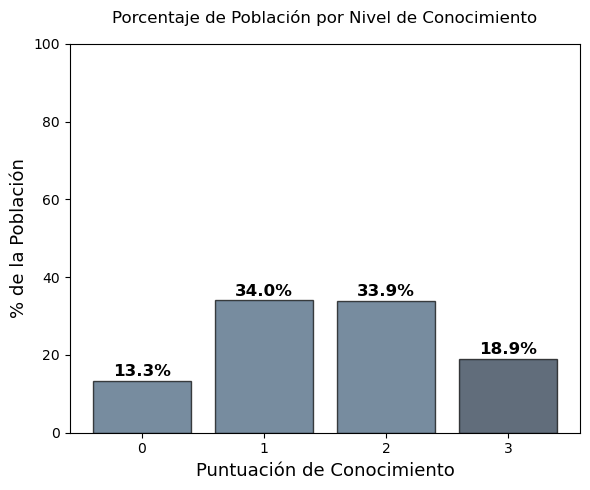

In [8]:
# 3.2 Gráfico 2: Porcentaje de población por nivel de conocimiento
# Propósito: Mostrar claramente qué porcentaje alcanza cada puntuación
print("\n GENERANDO GRÁFICO DE BARRAS POR NIVEL...")

# Calcular porcentajes ponderados por score
distribucion_ponderada = {}
for score in range(4):
    subset = datos_limpios[datos_limpios['score_conocimiento'] == score]
    pct = (subset['weight'].sum() / datos_limpios['weight'].sum()) * 100
    distribucion_ponderada[score] = pct

scores_list = list(distribucion_ponderada.keys())
pct_list = list(distribucion_ponderada.values())

# Colores según puntuación (gradiente lógico)
def get_color(score):
    if score <= 2:
        return COLOR_AZUL_CLARO   # Puntuaciones bajas = azul claro
    elif score <= 3:
        return COLOR_AZUL         # Puntuaciones medias = azul
    else:
        return COLOR_VERDE        # Puntuaciones altas = verde

colors = [get_color(score) for score in scores_list]

plt.figure(figsize=(6, 5))
bars = plt.bar(scores_list, pct_list, color=colors, edgecolor='black', alpha=0.7)

plt.xlabel('Puntuación de Conocimiento', fontsize=13)
plt.ylabel('% de la Población', fontsize=13)
plt.title('Porcentaje de Población por Nivel de Conocimiento', fontsize=12, pad=15)
plt.xticks(range(4))
plt.ylim(0, 100)

# Añadir valores numéricos sobre las barras
for bar, pct in zip(bars, pct_list):
    if pct > 0.1:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 3: VISUALIZACIÓN DE LA DISTRIBUCIÓN DEL CONOCIMIENTO
Se generan tres visualizaciones complementarias:
-  Histograma ponderado (distribución poblacional)
-  Gráfico de barras (% de población por nivel)
- Curva acumulada (para identificar mediana y percentiles)


 GENERANDO HISTOGRAMA PONDERADO...


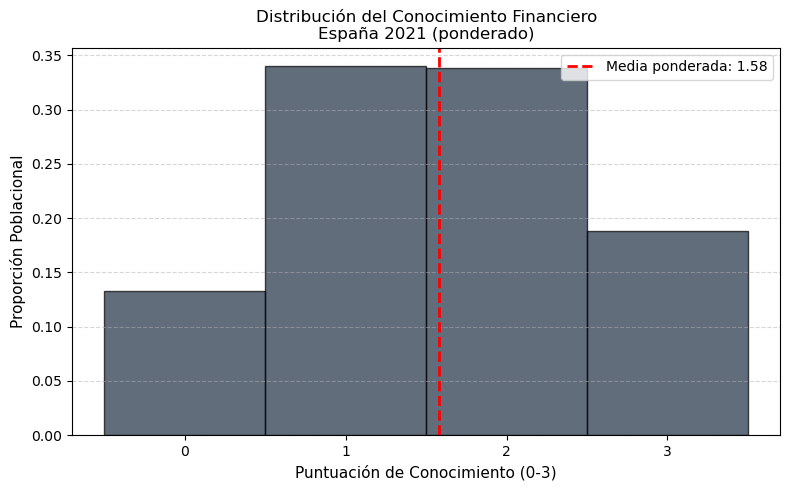

In [9]:
# 3.1 Gráfico 1: Histograma de distribución del score (ponderado)
# Propósito: Mostrar la forma de la distribución de manera continua
print("\n GENERANDO HISTOGRAMA PONDERADO...")

# Cálculo de Media Ponderada
media_ponderada = (datos_limpios['score_conocimiento'] * datos_limpios['weight']).sum() / datos_limpios['weight'].sum()

plt.figure(figsize=(8, 5))

scores_validos = datos_limpios['score_conocimiento'].dropna()
pesos_validos = datos_limpios.loc[scores_validos.index, 'weight']
pesos_norm = pesos_validos / pesos_validos.sum()  # Normalizar para obtener proporción

plt.hist(scores_validos, weights=pesos_norm,
         bins=np.arange(-0.5, 4.5, 1),
         edgecolor='black', color=COLOR_AZUL, alpha=0.7)

plt.xlabel('Puntuación de Conocimiento (0-3)', fontsize=11)
plt.ylabel('Proporción Poblacional', fontsize=11)
plt.title('Distribución del Conocimiento Financiero\nEspaña 2021 (ponderado)', fontsize=12)
plt.xticks(range(4))
plt.axvline(x=media_ponderada, color='red', linestyle='--', linewidth=2,
            label=f'Media ponderada: {media_ponderada:.2f}')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


 GENERANDO CURVA ACUMULADA...


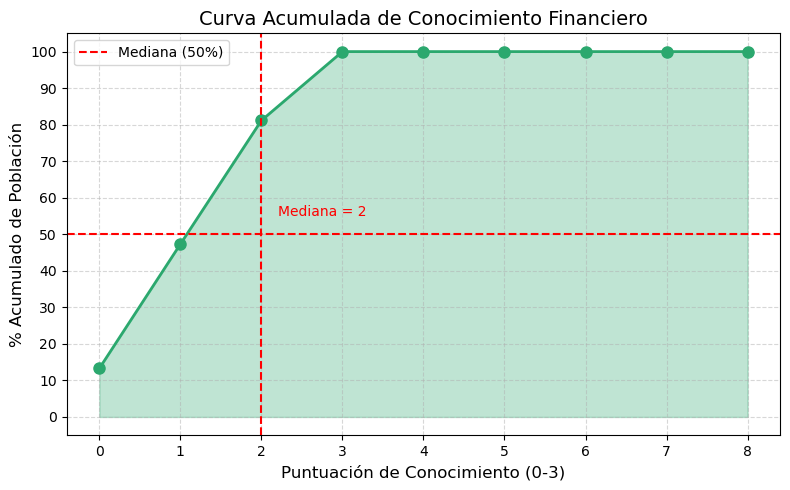

In [10]:
# 3.3 Gráfico 3: Curva acumulada
# Propósito: Identificar visualmente la mediana y la distribución acumulada
print("\n GENERANDO CURVA ACUMULADA...")

# Calcular porcentajes acumulados
acumulado = 0
acumulados = []
for score in range(9):
    subset = datos_limpios[datos_limpios['score_conocimiento'] == score]
    pct = (subset['weight'].sum() / datos_limpios['weight'].sum()) * 100
    acumulado += pct
    acumulados.append(acumulado)

plt.figure(figsize=(8, 5))
plt.plot(range(9), acumulados, marker='o', linewidth=2, color=COLOR_VERDE, markersize=8)
plt.fill_between(range(9), acumulados, alpha=0.3, color=COLOR_VERDE)

plt.xlabel('Puntuación de Conocimiento (0-3)', fontsize=12)
plt.ylabel('% Acumulado de Población', fontsize=12)
plt.title('Curva Acumulada de Conocimiento Financiero', fontsize=14)
plt.xticks(range(9))
plt.yticks(range(0, 101, 10))
plt.grid(True, linestyle='--', alpha=0.5)

# Línea de referencia del 50% (Mediana)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Mediana (50%)')

# Identificar el punto de la mediana
for score, acum in zip(range(9), acumulados):
    if acum >= 50:
        plt.axvline(x=score, color='red', linestyle='--', linewidth=1.5)
        plt.text(score + 0.2, 55, f'Mediana = {score}', fontsize=10, color='red')
        break

plt.legend()
plt.tight_layout()
plt.show()

####  3.1 ANÁLISIS DE CADA CONCEPTO POR SEPARADO (toda la base)
 Propósito: Identificar fortalezas y debilidades específicas en cada concepto

In [11]:
conceptos = {
        'e0600': 'Inflacion',
        'e0900': 'Interés Compuesto',
        'e1003': 'Diversificación del riesgo'
}

print("\n Porcentaje de acierto por concepto (ponderado):")
print("-"*55)

for var, nombre in conceptos.items():
    if var in datos_limpios.columns:
        # Calcular porcentaje de acierto ponderado
        aciertos = datos_limpios[datos_limpios[var] == preguntas_conocimiento.get(var, None)]
        pct_acierto = aciertos['weight'].sum() / datos_limpios['weight'].sum() * 100
        print(f"   {nombre}: {pct_acierto:.1f}%")


 Porcentaje de acierto por concepto (ponderado):
-------------------------------------------------------
   Inflacion: 65.0%
   Interés Compuesto: 41.3%
   Diversificación del riesgo: 52.0%


C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1781454627.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(etiquetas, fontsize=13, fontweight='bold')


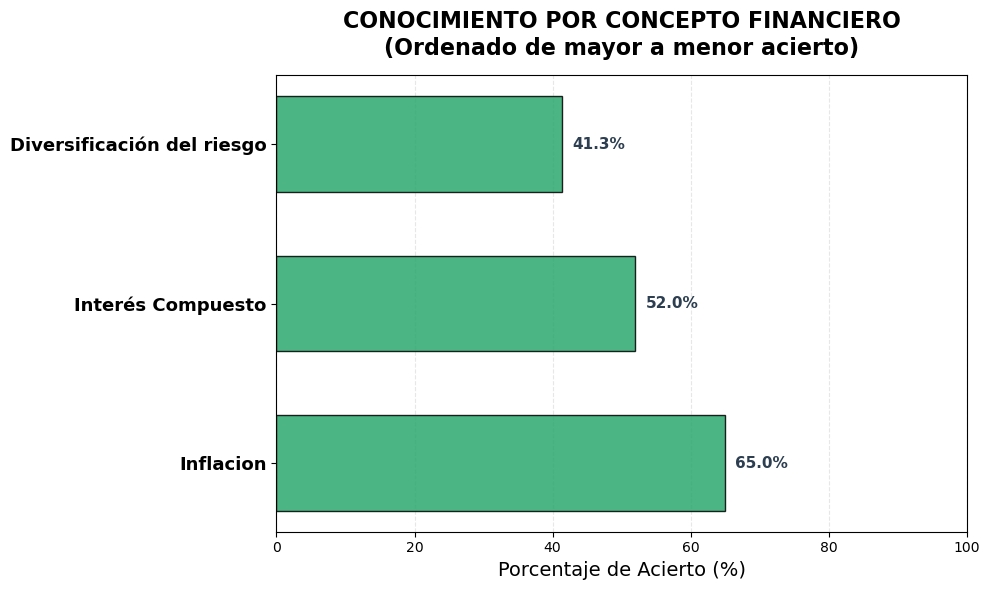

In [12]:
# Visualización
import matplotlib.pyplot as plt

# Paleta de colores (definida previamente)
COLOR_VERDE = '#2BA86E'

conceptos = {
    'e0600': 'Inflacion',
    'e0900': 'Interés Compuesto',
    'e1003': 'Diversificación del riesgo'
}
aciertos = [65.0, 52.0, 41.3]

# Extraer las etiquetas (valores del diccionario)
etiquetas = list(conceptos.values())  # ['Inflacion', 'Interés Compuesto', 'Diversificación del riesgo']

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

# Barras horizontales (todas del mismo color verde)
bars = ax.barh(etiquetas, aciertos, color=COLOR_VERDE, edgecolor='black', 
               alpha=0.85, height=0.6, zorder=2)

# Personalizar ejes
ax.set_xlim(0, 100)
ax.set_xlabel('Porcentaje de Acierto (%)', fontsize=14)
ax.set_title('CONOCIMIENTO POR CONCEPTO FINANCIERO\n(Ordenado de mayor a menor acierto)', 
             fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)

ax.set_yticklabels(etiquetas, fontsize=13, fontweight='bold')

# Añadir valores al final de cada barra
for bar, score in zip(bars, aciertos):
    ax.text(score + 1.5, bar.get_y() + bar.get_height()/2, 
            f'{score:.1f}%', ha='left', va='center', 
            fontweight='bold', fontsize=11, color='#2C3E50')


plt.tight_layout()
plt.show()

### 4: ANÁLISIS POR PERFILES DEMOGRÁFICOS
Explicación: Se segmenta el conocimiento conceptual por:
 - Edad (grupos etarios)
 - Nivel educativo (según cuestionario a1100)
 - Nivel de renta (según cuestionario j1300)

####  4.1 ANÁLISIS POR EDAD
 Propósito: Identificar cómo varía el conocimiento a lo largo del ciclo vital

In [13]:
# BLOQUE 1: CREAR GRUPOS DE EDAD 

if 'age' in datos_limpios.columns:
    datos_limpios['grupo_edad'] = pd.cut(
        datos_limpios['age'],
        bins=[17, 34, 44, 54, 64, 80],
        labels=['18-34', '35-44', '45-54', '55-64', '65+']
    )
    print(" Grupos de edad creados")
    print(f"   Distribución: {datos_limpios['grupo_edad'].value_counts().to_dict()}")
else:
    print(" Variable 'age' no encontrada")

 Grupos de edad creados
   Distribución: {'18-34': 1899, '45-54': 1802, '35-44': 1471, '55-64': 1440, '65+': 1152}


In [14]:
# CALCULAR SCORE DE CONOCIMIENTO POR EDAD

if 'grupo_edad' in datos_limpios.columns:
    
    print("\n" + "="*50)
    print("SCORE DE CONOCIMIENTO POR GRUPO DE EDAD")
    print("="*50)
    
    score_edad = {}
    for grupo in datos_limpios['grupo_edad'].cat.categories:
        subset = datos_limpios[datos_limpios['grupo_edad'] == grupo]
        score = weighted_mean(subset, 'score_conocimiento')
        score_edad[grupo] = score
        print(f"\n   {grupo}:")
        print(f"      - Puntuación media: {score:.3f} puntos (sobre 3)")
        print(f"      - Muestra: {len(subset)} personas")
else:
    print(" 'grupo_edad' no existe. Ejecuta bloque 1 primero.")


SCORE DE CONOCIMIENTO POR GRUPO DE EDAD

   18-34:
      - Puntuación media: 1.546 puntos (sobre 3)
      - Muestra: 1899 personas

   35-44:
      - Puntuación media: 1.571 puntos (sobre 3)
      - Muestra: 1471 personas

   45-54:
      - Puntuación media: 1.681 puntos (sobre 3)
      - Muestra: 1802 personas

   55-64:
      - Puntuación media: 1.679 puntos (sobre 3)
      - Muestra: 1440 personas

   65+:
      - Puntuación media: 1.432 puntos (sobre 3)
      - Muestra: 1152 personas


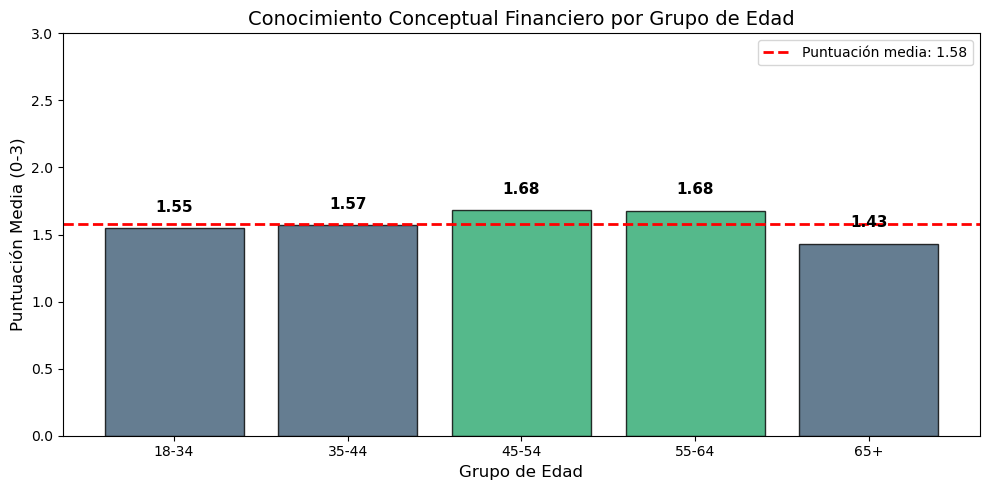


RESUMEN DE COLORES POR GRUPO DE EDAD
Media ponderada de referencia: 1.58

18-34: 1.546 - ✗ NO supera media (AZUL CLARO)
35-44: 1.571 - ✗ NO supera media (AZUL CLARO)
45-54: 1.681 - ✓ SUPERA media (VERDE)
55-64: 1.679 - ✓ SUPERA media (VERDE)
65+: 1.432 - ✗ NO supera media (AZUL CLARO)


In [15]:
# VISUALIZACIÓN - CONOCIMIENTO POR EDAD

if 'score_edad' in locals() and len(score_edad) > 0:
    
    plt.figure(figsize=(10, 5))
    
    grupos = list(score_edad.keys())
    scores = list(score_edad.values())
    
    # Calcular media ponderada (si no está calculada previamente)
    # media_ponderada = (datos_limpios['score_conocimiento'] * datos_limpios['weight']).sum() / datos_limpios['weight'].sum()
    media_ponderada = 1.58  # Valor conocido según los datos mostrados
    
    # Definir colores según si superan la media ponderada
    colores_barra = []
    for score in scores:
        if score >= media_ponderada:
            colores_barra.append(COLOR_VERDE)  # Verde para los que SUPERAN o IGUALAN la media
        else:
            colores_barra.append(COLOR_AZUL_CLARO)  # Azul claro para los que NO superan la media
    
    bars = plt.bar(grupos, scores, 
                   color=colores_barra, 
                   edgecolor='black', alpha=0.8)
    
    # Línea de referencia de la media ponderada
    plt.axhline(y=media_ponderada, color='red', linestyle='--', linewidth=2, 
                label=f'Puntuación media: {media_ponderada:.2f}')
    plt.legend()
    
    plt.xlabel('Grupo de Edad', fontsize=12)
    plt.ylabel('Puntuación Media (0-3)', fontsize=12)
    plt.title('Conocimiento Conceptual Financiero por Grupo de Edad', fontsize=14)
    plt.ylim(0, 3.0)
    
    # Añadir valores en las barras
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir resumen de colores
    print("\n" + "="*50)
    print("RESUMEN DE COLORES POR GRUPO DE EDAD")
    print("="*50)
    print(f"Media ponderada de referencia: {media_ponderada:.2f}\n")
    for grupo, score, color in zip(grupos, scores, colores_barra):
        status = "✓ SUPERA media" if score >= media_ponderada else "✗ NO supera media"
        color_name = "VERDE" if color == COLOR_VERDE else "AZUL CLARO"
        print(f"{grupo}: {score:.3f} - {status} ({color_name})")
    
elif 'score_edad' not in locals():
    print(" 'score_edad' no existe. Ejecuta bloque 2 primero.")
else:
    print(" No hay datos para graficar")

In [16]:
#  IDENTIFICAR GRUPO DE EDAD CON MAYOR CONOCIMIENTO

if 'score_edad' in locals() and len(score_edad) > 0:
    mejor_edad = max(score_edad, key=score_edad.get)
    print(f"\n Grupo de edad con MAYOR conocimiento: {mejor_edad} ({score_edad[mejor_edad]:.3f} puntos)")
else:
    print(" 'score_edad' no existe. Ejecuta bloque 2 primero.")


 Grupo de edad con MAYOR conocimiento: 45-54 (1.681 puntos)


In [17]:
#  IDENTIFICAR GRUPO DE EDAD CON MENOR CONOCIMIENTO

if 'score_edad' in locals() and len(score_edad) > 0:
    peor_edad = min(score_edad, key=score_edad.get)
    print(f"\n Grupo de edad con MENOR conocimiento: {peor_edad} ({score_edad[peor_edad]:.3f} puntos)")
else:
    print(" 'score_edad' no existe. Ejecuta bloque 2 primero.")


 Grupo de edad con MENOR conocimiento: 65+ (1.432 puntos)


In [18]:
#  CALCULAR BRECHA GENERACIONAL

if 'score_edad' in locals() and len(score_edad) > 0:
    mejor_edad = max(score_edad, key=score_edad.get)
    peor_edad = min(score_edad, key=score_edad.get)
    brecha_edad = score_edad[mejor_edad] - score_edad[peor_edad]
    
    print("\n" + "="*50)
    print(" BRECHA GENERACIONAL")
    print("="*50)
    print(f"   Mayor conocimiento: {mejor_edad} ({score_edad[mejor_edad]:.3f} puntos)")
    print(f"   Menor conocimiento: {peor_edad} ({score_edad[peor_edad]:.3f} puntos)")
    print(f"   DIFERENCIA: {brecha_edad:.3f} puntos")
    print(f"\n    La brecha generacional es de {brecha_edad/5*100:.1f}%")
else:
    print(" 'score_edad' no existe. Ejecuta bloque 2 primero.")


 BRECHA GENERACIONAL
   Mayor conocimiento: 45-54 (1.681 puntos)
   Menor conocimiento: 65+ (1.432 puntos)
   DIFERENCIA: 0.250 puntos

    La brecha generacional es de 5.0%


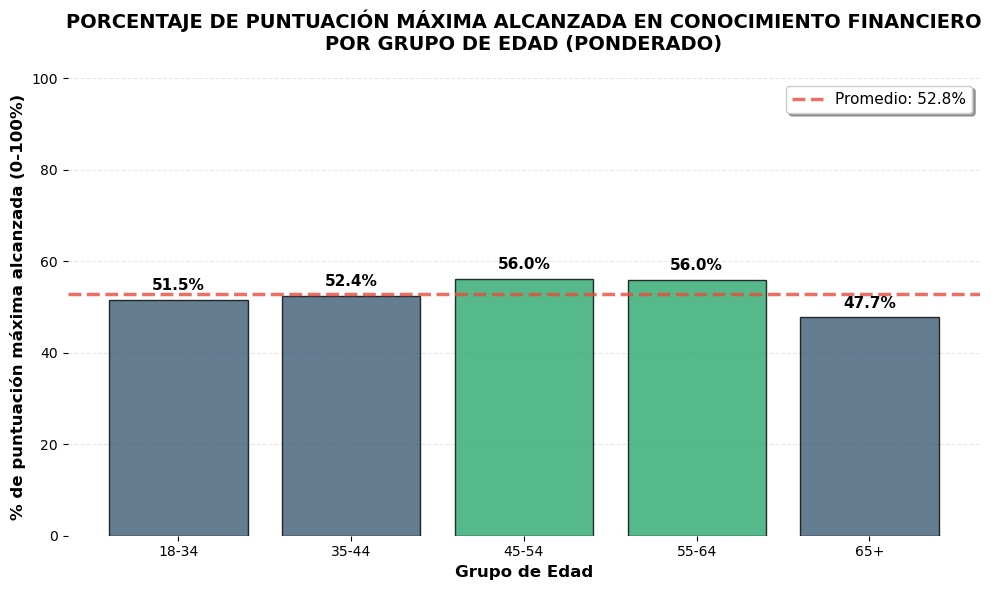


% DE PUNTUACIÓN MÁXIMA ALCANZADA POR GRUPO DE EDAD (PONDERADO)
  18-34   : 51.5% (-1.2 pp vs promedio) - Score: 1.55/3
  35-44   : 52.4% (-0.4 pp vs promedio) - Score: 1.57/3
  45-54   : 56.0% (+3.3 pp vs promedio) - Score: 1.68/3
  55-64   : 56.0% (+3.2 pp vs promedio) - Score: 1.68/3
  65+     : 47.7% (-5.0 pp vs promedio) - Score: 1.43/3

Promedio poblacional total: 52.8% (Score: 1.58/3)


In [19]:
# ============================================================================
# GRÁFICO: % DE PUNTUACIÓN MÁXIMA ALCANZADA POR GRUPO DE EDAD (PONDERADO)
# ============================================================================

import matplotlib.pyplot as plt

# Calcular porcentaje ponderado de puntuación máxima (score/3*100) por grupo de edad
pct_puntuacion_max_por_edad = {}

for grupo in datos_limpios['grupo_edad'].cat.categories:
    subset = datos_limpios[datos_limpios['grupo_edad'] == grupo]
    # Score medio ponderado del grupo
    score_medio = (subset['score_conocimiento'] * subset['weight']).sum() / subset['weight'].sum()
    # Convertir a porcentaje sobre la puntuación máxima (3)
    pct = (score_medio / 3) * 100
    pct_puntuacion_max_por_edad[grupo] = pct

# Calcular promedio ponderado general (línea de referencia)
score_medio_general = (datos_limpios['score_conocimiento'] * datos_limpios['weight']).sum() / datos_limpios['weight'].sum()
promedio_general_pct = (score_medio_general / 3) * 100

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))

grupos = list(pct_puntuacion_max_por_edad.keys())
porcentajes = list(pct_puntuacion_max_por_edad.values())

# Barras con colores según superen o no el promedio
colores = [COLOR_VERDE if p >= promedio_general_pct else COLOR_AZUL_CLARO for p in porcentajes]

bars = ax.bar(grupos, porcentajes, color=colores, edgecolor='black', alpha=0.8, zorder=2)

# Línea del promedio general
ax.axhline(y=promedio_general_pct, color=COLOR_ROJO, linestyle='--', 
           linewidth=2.5, alpha=0.8, zorder=3, 
           label=f'Promedio: {promedio_general_pct:.1f}%')

# Etiquetas en las barras
for bar, pct in zip(bars, porcentajes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Personalización
ax.set_ylabel('% de puntuación máxima alcanzada (0-100%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Grupo de Edad', fontsize=12, fontweight='bold')
ax.set_title('PORCENTAJE DE PUNTUACIÓN MÁXIMA ALCANZADA EN CONOCIMIENTO FINANCIERO\nPOR GRUPO DE EDAD (PONDERADO)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Limpieza visual
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Imprimir resultados
print("\n" + "="*60)
print("% DE PUNTUACIÓN MÁXIMA ALCANZADA POR GRUPO DE EDAD (PONDERADO)")
print("="*60)
for grupo, pct in pct_puntuacion_max_por_edad.items():
    dif = pct - promedio_general_pct
    signo = "+" if dif > 0 else ""
    # Calcular score real para referencia
    subset = datos_limpios[datos_limpios['grupo_edad'] == grupo]
    score_real = (subset['score_conocimiento'] * subset['weight']).sum() / subset['weight'].sum()
    print(f"  {grupo:8}: {pct:.1f}% ({signo}{dif:.1f} pp vs promedio) - Score: {score_real:.2f}/3")

print("\n" + "="*60)
print(f"Promedio poblacional total: {promedio_general_pct:.1f}% (Score: {score_medio_general:.2f}/3)")
print("="*60)

#### 4.2 ANÁLISIS POR NIVEL EDUCATIVO (usando a1100)
 Propósito: Evaluar la relación entre educación formal y conocimiento financiero

In [20]:
#  Verificar la variable educativa correcta
if 'a1100' in datos_limpios.columns:
    print(" Variable 'a1100' encontrada (Nivel educativo según cuestionario)")
    print("\n Distribución de valores en a1100:")
    print(datos_limpios['a1100'].value_counts().sort_index())
else:
    print(" Variable 'a1100' NO encontrada")
    print("   Buscando alternativas...")
    for col in datos_limpios.columns:
        if 'educ' in col.lower() or 'estudio' in col.lower():
            print(f"   Posible alternativa: '{col}'")

 Variable 'a1100' encontrada (Nivel educativo según cuestionario)

 Distribución de valores en a1100:
a1100
1      68
2     795
3    1717
4    1835
5      97
6    1033
7     729
8    1400
9      90
Name: count, dtype: int64


In [21]:
# MAPEO DE CÓDIGOS A NIVEL EDUCATIVO (solo si a1100 existe)

if 'a1100' in datos_limpios.columns:
    
    mapa_educacion_oficial = {
        1: 'Menos de primaria',
        2: 'Educación primaria',
        3: 'Secundaria (1ª etapa) - ESO',
        4: 'Secundaria (2ª etapa) - Bachillerato/FP Grado Medio',
        5: 'Educación postsecundaria no superior',
        6: 'FP Grado Superior',
        7: 'Diplomatura/Grado universitario',
        8: 'Licenciatura/Máster',
        9: 'Doctorado',
        10: 'Otros'
    }
    
    datos_limpios['nivel_educativo_detalle'] = datos_limpios['a1100'].map(mapa_educacion_oficial)
    
    print("\n NIVEL EDUCATIVO DETALLADO:")
    print(datos_limpios['nivel_educativo_detalle'].value_counts(dropna=False))
else:
    print(" No se puede mapear: 'a1100' no existe")


 NIVEL EDUCATIVO DETALLADO:
nivel_educativo_detalle
Secundaria (2ª etapa) - Bachillerato/FP Grado Medio    1835
Secundaria (1ª etapa) - ESO                            1717
Licenciatura/Máster                                    1400
FP Grado Superior                                      1033
Educación primaria                                      795
Diplomatura/Grado universitario                         729
Educación postsecundaria no superior                     97
Doctorado                                                90
Menos de primaria                                        68
Name: count, dtype: int64


In [22]:
# CREAR CATEGORÍAS SIMPLIFICADAS (Básico, Medio, Alto)

if 'a1100' in datos_limpios.columns:
    
    def simplificar_educacion_oficial(valor):
        if pd.isna(valor):
            return None
        if valor in [1, 2,3]:
            return 'Prebachillerato'
        elif valor in [ 4, 5]:
            return 'Bachillerato'
        elif valor in [6, 7, 8, 9]:
            return 'Universitario o equivalente'
        elif valor == 10:
            return 'Otros'
        else:
            return None
    
    datos_limpios['educacion_categoria'] = datos_limpios['a1100'].apply(simplificar_educacion_oficial)
    
    print("\n CATEGORÍAS SIMPLIFICADAS:")
    print(datos_limpios['educacion_categoria'].value_counts(dropna=False))
else:
    print(" No se pueden crear categorías: 'a1100' no existe")


 CATEGORÍAS SIMPLIFICADAS:
educacion_categoria
Universitario o equivalente    3252
Prebachillerato                2580
Bachillerato                   1932
Name: count, dtype: int64


In [23]:
# CALCULAR SCORE DE CONOCIMIENTO POR CATEGORÍA EDUCATIVA

if 'educacion_categoria' in datos_limpios.columns:
    
    print("\n" + "="*50)
    print("SCORE DE CONOCIMIENTO POR NIVEL EDUCATIVO")
    print("="*50)
    
    score_educacion = {}
    for categoria in datos_limpios['educacion_categoria'].dropna().unique():
        subset = datos_limpios[datos_limpios['educacion_categoria'] == categoria]
        if len(subset) >= 30:
            score = weighted_mean(subset, 'score_conocimiento')
            score_educacion[categoria] = score
            print(f"\n   {categoria}:")
            print(f"      - Puntuación media: {score:.3f} puntos (sobre 3)")
            print(f"      - Muestra: {len(subset)} personas")
else:
    print(" 'educacion_categoria' no existe. Ejecuta bloques anteriores primero.")


SCORE DE CONOCIMIENTO POR NIVEL EDUCATIVO

   Universitario o equivalente:
      - Puntuación media: 1.919 puntos (sobre 3)
      - Muestra: 3252 personas

   Bachillerato:
      - Puntuación media: 1.646 puntos (sobre 3)
      - Muestra: 1932 personas

   Prebachillerato:
      - Puntuación media: 1.272 puntos (sobre 3)
      - Muestra: 2580 personas


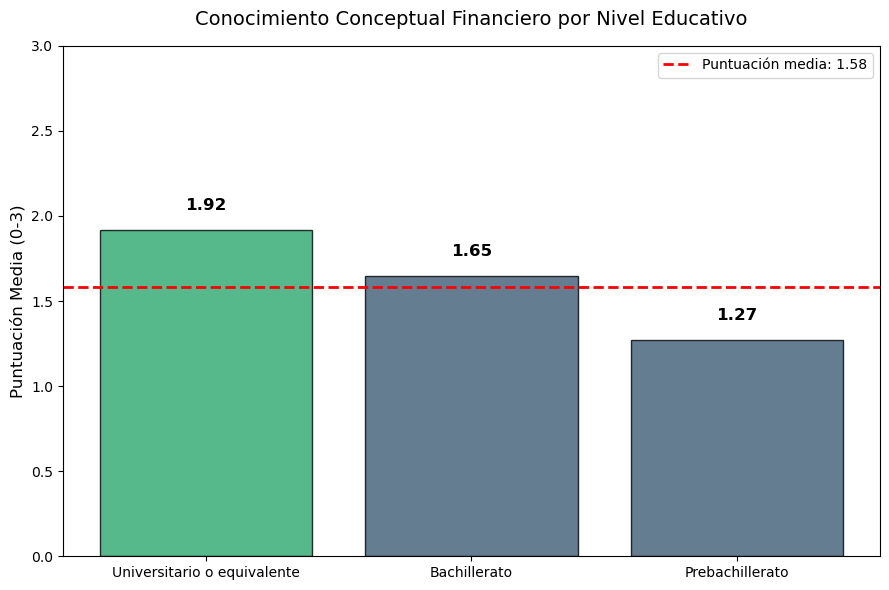

In [24]:
#  VISUALIZACIÓN DEL CONOCIMIENTO POR EDUCACIÓN

if 'score_educacion' in locals() and len(score_educacion) >= 2:
    
    # Ordenar por score descendente
    score_educacion = dict(sorted(score_educacion.items(), key=lambda x: x[1], reverse=True))
    
    plt.figure(figsize=(9, 6))
    
    categorias = list(score_educacion.keys())
    scores = list(score_educacion.values())
    
    # Colores según categoría
    colors = []
    for cat in categorias:
        if 'Universitario o equivalente' in cat:
            colors.append(COLOR_VERDE)
        elif 'Bachillerato' in cat:
            colors.append(COLOR_AZUL_CLARO)
        else:
            colors.append(COLOR_AZUL_CLARO)
    
    bars = plt.bar(categorias, scores, color=colors, edgecolor='black', alpha=0.8)
    
    # Línea de referencia
    media_nacional = weighted_mean(datos_limpios, 'score_conocimiento')
    plt.axhline(y=media_nacional, color='red', linestyle='--', linewidth=2, 
                label=f'Puntuación media: {media_nacional:.2f}')
    plt.legend()
    
    #plt.xlabel('Nivel Educativo', fontsize=12)
    plt.ylabel('Puntuación Media (0-3)', fontsize=12)
    plt.title('Conocimiento Conceptual Financiero por Nivel Educativo', fontsize=14, pad=15)
    plt.ylim(0, 3)
    
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
elif 'score_educacion' in locals():
    print(" No hay suficientes categorías educativas para graficar")
else:
    print(" 'score_educacion' no existe. Ejecuta bloque 4 primero.")

In [25]:
#  CALCULAR BRECHA EDUCATIVA

if 'score_educacion' in locals():
    if 'Universitario o equivalente' in score_educacion and 'Prebachillerato' in score_educacion:
        brecha = score_educacion['Universitario o equivalente'] - score_educacion['Prebachillerato']
        
        print("\n" + "="*50)
        print(" BRECHA EDUCATIVA")
        print("="*50)
        print(f"   Universitario o equivalente: {score_educacion['Universitario o equivalente']:.3f} puntos")
        print(f"   Prebachillerato: {score_educacion['Prebachillerato']:.3f} puntos")
        print(f"   DIFERENCIA: {brecha:.3f} puntos")
        print(f"\n    Los universitarios tienen un conocimiento conceptual")
        print(f"      {brecha/5*100:.1f}% más alto que quienes tienen educación básica")
    else:
        print(" No se puede calcular brecha: faltan categorías")
else:
    print(" 'score_educacion' no existe. Ejecuta bloque 4 primero.")


 BRECHA EDUCATIVA
   Universitario o equivalente: 1.919 puntos
   Prebachillerato: 1.272 puntos
   DIFERENCIA: 0.646 puntos

    Los universitarios tienen un conocimiento conceptual
      12.9% más alto que quienes tienen educación básica


In [26]:
# PORCENTAJE DE ACIERTO POR CONCEPTO Y NIVEL EDUCATIVO

if 'score_educacion' in locals():
    
    print("\n" + "="*50)
    print("PORCENTAJE DE ACIERTO POR CONCEPTO Y NIVEL EDUCATIVO")
    print("="*50)
    
    conceptos_educ = {
        'e0600': 'Inflacion',
        'e0900': 'Interés Compuesto',
        'e1003': 'Diversificación del riesgo'
    }
    
    for categoria in score_educacion.keys():
        subset = datos_limpios[datos_limpios['educacion_categoria'] == categoria]
        print(f"\n   {categoria}:")
        for var, nombre in conceptos_educ.items():
            if var in subset.columns:
                correcta = preguntas_conocimiento.get(var)
                if correcta is not None:
                    aciertos = subset[subset[var] == correcta]
                    pct = aciertos['weight'].sum() / subset['weight'].sum() * 100
                    print(f"      - {nombre}: {pct:.1f}%")
else:
    print(" 'score_educacion' no existe. Ejecuta bloque 4 primero.")


PORCENTAJE DE ACIERTO POR CONCEPTO Y NIVEL EDUCATIVO

   Universitario o equivalente:
      - Inflacion: 77.3%
      - Interés Compuesto: 50.9%
      - Diversificación del riesgo: 63.7%

   Bachillerato:
      - Inflacion: 67.0%
      - Interés Compuesto: 44.7%
      - Diversificación del riesgo: 52.8%

   Prebachillerato:
      - Inflacion: 53.8%
      - Interés Compuesto: 31.4%
      - Diversificación del riesgo: 42.1%


      - Inflación (definición): 94.0%
      - Diversificación del riesgo: 63.7%

   Medio (Secundaria/FP):
      - Inflación (pérdida poder adquisitivo): 61.0%
      - Interés compuesto (5 años): 39.4%
      - Riesgo-Rentabilidad: 84.1%
      - Inflación (definición): 87.6%
      - Diversificación del riesgo: 48.7%

   Básico (Primaria o menos):
      - Inflación (pérdida poder adquisitivo): 50.3%
      - Interés compuesto (5 años): 25.8%
      - Riesgo-Rentabilidad: 70.4%
      - Inflación (definición): 85.8%
      - Diversificación del riesgo: 36.8%


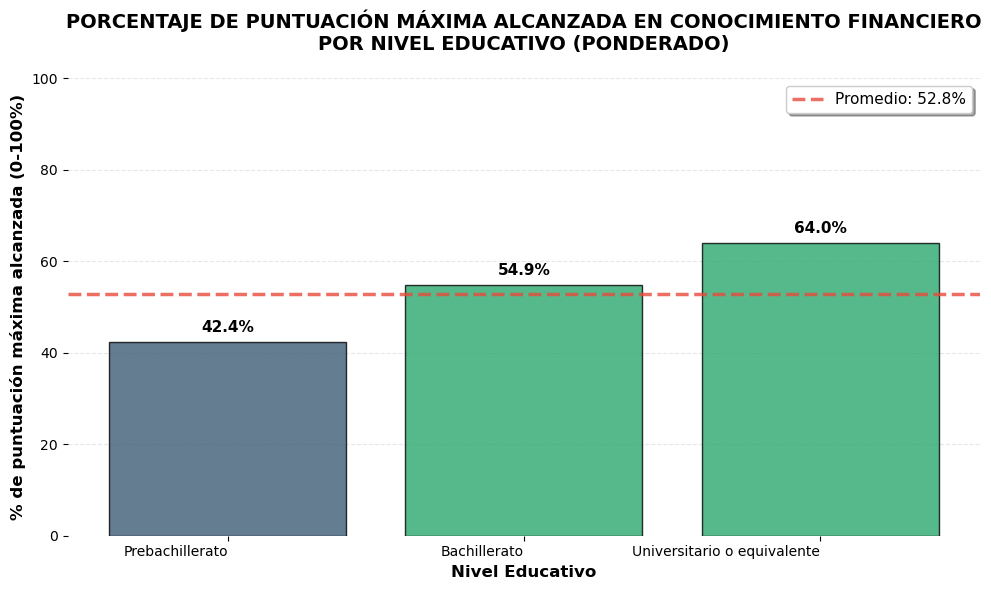


% DE PUNTUACIÓN MÁXIMA ALCANZADA POR NIVEL EDUCATIVO (PONDERADO)
  Prebachillerato: 42.4% (-10.3 pp vs promedio) - Score: 1.27/3
  Bachillerato: 54.9% (+2.1 pp vs promedio) - Score: 1.65/3
  Universitario o equivalente: 64.0% (+11.2 pp vs promedio) - Score: 1.92/3

Promedio poblacional total: 52.8% (Score: 1.58/3)


In [27]:
# ============================================================================
# GRÁFICO: % DE PUNTUACIÓN MÁXIMA ALCANZADA POR NIVEL EDUCATIVO (PONDERADO)
# ============================================================================

import matplotlib.pyplot as plt

# Calcular porcentaje ponderado de puntuación máxima (score/3*100) por nivel educativo
pct_puntuacion_max_por_educacion = {}

# Usar unique() en lugar de cat.categories (funciona con cualquier tipo de dato)
for grupo in datos_limpios['educacion_categoria'].dropna().unique():
    subset = datos_limpios[datos_limpios['educacion_categoria'] == grupo]
    # Score medio ponderado del grupo
    score_medio = (subset['score_conocimiento'] * subset['weight']).sum() / subset['weight'].sum()
    # Convertir a porcentaje sobre la puntuación máxima (3)
    pct = (score_medio / 3) * 100
    pct_puntuacion_max_por_educacion[grupo] = pct

# Calcular promedio ponderado general (línea de referencia)
score_medio_general = (datos_limpios['score_conocimiento'] * datos_limpios['weight']).sum() / datos_limpios['weight'].sum()
promedio_general_pct = (score_medio_general / 3) * 100

# Ordenar por nivel educativo (de menor a mayor)
orden_educacion = ['Prebachillerato', 'Bachillerato', 'Universitario o equivalente']
pct_puntuacion_max_por_educacion_ordenado = {k: pct_puntuacion_max_por_educacion[k] for k in orden_educacion if k in pct_puntuacion_max_por_educacion}

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))

grupos = list(pct_puntuacion_max_por_educacion_ordenado.keys())
porcentajes = list(pct_puntuacion_max_por_educacion_ordenado.values())

# Barras con colores según superen o no el promedio
colores = [COLOR_VERDE if p >= promedio_general_pct else COLOR_AZUL_CLARO for p in porcentajes]

bars = ax.bar(grupos, porcentajes, color=colores, edgecolor='black', alpha=0.8, zorder=2)

# Línea del promedio general
ax.axhline(y=promedio_general_pct, color=COLOR_ROJO, linestyle='--', 
           linewidth=2.5, alpha=0.8, zorder=3, 
           label=f'Promedio: {promedio_general_pct:.1f}%')

# Etiquetas en las barras
for bar, pct in zip(bars, porcentajes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Personalización
ax.set_ylabel('% de puntuación máxima alcanzada (0-100%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nivel Educativo', fontsize=12, fontweight='bold')
ax.set_title('PORCENTAJE DE PUNTUACIÓN MÁXIMA ALCANZADA EN CONOCIMIENTO FINANCIERO\nPOR NIVEL EDUCATIVO (PONDERADO)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0,100)
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Rotar etiquetas si son largas
plt.xticks(rotation=0, ha='right', fontsize=10)


# Limpieza visual
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Imprimir resultados
print("\n" + "="*60)
print("% DE PUNTUACIÓN MÁXIMA ALCANZADA POR NIVEL EDUCATIVO (PONDERADO)")
print("="*60)
for grupo, pct in pct_puntuacion_max_por_educacion_ordenado.items():
    dif = pct - promedio_general_pct
    signo = "+" if dif > 0 else ""
    # Calcular score real para referencia
    subset = datos_limpios[datos_limpios['educacion_categoria'] == grupo]
    score_real = (subset['score_conocimiento'] * subset['weight']).sum() / subset['weight'].sum()
    print(f"  {grupo}: {pct:.1f}% ({signo}{dif:.1f} pp vs promedio) - Score: {score_real:.2f}/3")

print("\n" + "="*60)
print(f"Promedio poblacional total: {promedio_general_pct:.1f}% (Score: {score_medio_general:.2f}/3)")
print("="*60)

####  4.4 ANÁLISIS POR NIVEL DE RENTA (usando j1300)
 Propósito: Evaluar la relación entre ingresos y conocimiento financiero

In [28]:
#  VERIFICAR SI EXISTE LA VARIABLE DE RENTA

if 'j1300' in datos_limpios.columns:
    print(" Variable 'j1300' encontrada (Ingresos brutos anuales del hogar)")
    
    # Ver valores únicos y frecuencias
    print("\n VALORES ÚNICOS EN j1300 (códigos del cuestionario):")
    print(datos_limpios['j1300'].value_counts().sort_index())
    
    # Valores nulos
    nulos = datos_limpios['j1300'].isna().sum()
    print(f"\n Valores nulos: {nulos} ({nulos/len(datos_limpios)*100:.1f}%)")
else:
    print(" Variable 'j1300' no encontrada")
    print("   Buscando alternativas...")
    alternativas_renta = ['a1700', 'renta', 'income', 'ingresos', 'j1300']
    for col in datos_limpios.columns:
        if any(alt in col.lower() for alt in alternativas_renta):
            print(f"   ¿Quizás usar '{col}'? (valores: {datos_limpios[col].dropna().unique()[:5]})")

 Variable 'j1300' encontrada (Ingresos brutos anuales del hogar)

 VALORES ÚNICOS EN j1300 (códigos del cuestionario):
j1300
-5.0      20
 1.0     563
 2.0    1149
 3.0    1944
 4.0    2116
 5.0     990
 6.0     520
Name: count, dtype: int64

 Valores nulos: 462 (6.0%)


In [29]:
#  LIMPIAR DATOS DE RENTA (eliminar códigos negativos)

if 'j1300' in datos_limpios.columns:
    
    renta_limpia = datos_limpios[datos_limpios['j1300'] >= 0].copy()
    print(f"\n Datos válidos de renta: {len(renta_limpia)} personas ({len(renta_limpia)/len(datos_limpios)*100:.1f}%)")
    
    if len(renta_limpia) <= 100:
        print(f"\n Datos de renta insuficientes para análisis significativo")
        print(f"   Solo {len(renta_limpia)} personas tienen datos válidos de renta")
else:
    print(" No se puede limpiar: 'j1300' no existe")


 Datos válidos de renta: 7282 personas (93.8%)


In [30]:
#  CREAR GRUPOS DE RENTA (según categorías del cuestionario)

if 'j1300' in datos_limpios.columns :
    
    def grupo_renta(valor):
        if valor == 1:
            return '< 9.5k€'
        elif valor == 2:
            return '9.5k - 15k€'
        elif valor == 3:
            return '15k - 27k€'
        elif valor == 4:
            return '27k - 47k€'
        elif valor == 5:
            return '47k - 71k€'
        elif valor == 6:
            return '71k€'
        else:
            return None
    
    datos_limpios['renta_grupo'] = datos_limpios['j1300'].apply(grupo_renta)
    
    print("\n DISTRIBUCIÓN DE GRUPOS DE RENTA:")
    print(datos_limpios['renta_grupo'].value_counts().sort_index())
else:
    print(" No se pueden crear grupos: datos insuficientes")


 DISTRIBUCIÓN DE GRUPOS DE RENTA:
renta_grupo
15k - 27k€     1944
27k - 47k€     2116
47k - 71k€      990
71k€            520
9.5k - 15k€    1149
< 9.5k€         563
Name: count, dtype: int64


In [31]:
# CALCULAR SCORE DE CONOCIMIENTO POR NIVEL DE RENTA

if 'renta_grupo' in datos_limpios.columns:
    
    print("\n" + "="*50)
    print("SCORE DE CONOCIMIENTO POR NIVEL DE RENTA")
    print("="*50)
    
    score_renta = {}
    for grupo in datos_limpios['renta_grupo'].dropna().unique():
        subset = datos_limpios[datos_limpios['renta_grupo'] == grupo]
        if len(subset) >= 30:
            score = weighted_mean(subset, 'score_conocimiento')
            score_renta[grupo] = score
            print(f"\n   {grupo}:")
            print(f"      - Puntuación media: {score:.3f} puntos (sobre 3)")
            print(f"      - Muestra: {len(subset)} personas")
else:
    print(" 'renta_grupo' no existe. Ejecuta bloque 3 primero.")


SCORE DE CONOCIMIENTO POR NIVEL DE RENTA

   27k - 47k€:
      - Puntuación media: 1.750 puntos (sobre 3)
      - Muestra: 2116 personas

   9.5k - 15k€:
      - Puntuación media: 1.346 puntos (sobre 3)
      - Muestra: 1149 personas

   71k€:
      - Puntuación media: 2.194 puntos (sobre 3)
      - Muestra: 520 personas

   15k - 27k€:
      - Puntuación media: 1.465 puntos (sobre 3)
      - Muestra: 1944 personas

   47k - 71k€:
      - Puntuación media: 1.950 puntos (sobre 3)
      - Muestra: 990 personas

   < 9.5k€:
      - Puntuación media: 1.204 puntos (sobre 3)
      - Muestra: 563 personas


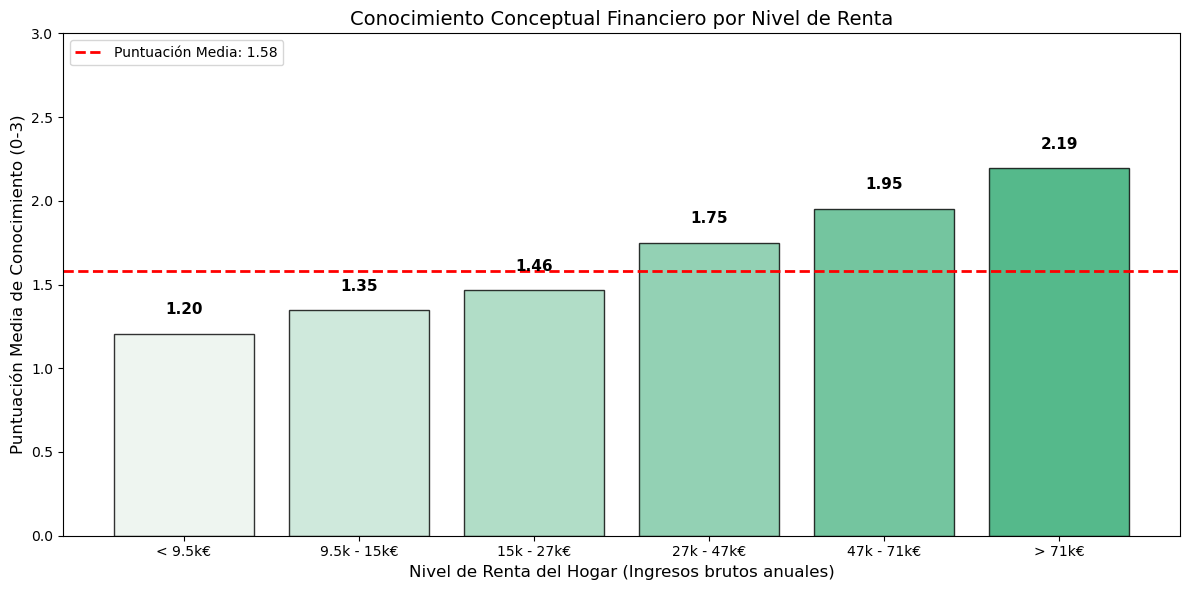

In [32]:
#  VISUALIZACIÓN DEL CONOCIMIENTO POR NIVEL DE RENTA 

if 'score_renta' in locals() and len(score_renta) >= 2:
    
    # Definir rangos de renta (versión CORTA para gráfico)
    # Mapeo de nombres largos a nombres cortos
    renta_labels_cortos = {
        '< 9.5k€': '< 9.5k€',
        '9.5k - 15k€': '9.5k - 15k€',
        '15k - 27k€': '15k - 27k€',
        '27k - 47k€': '27k - 47k€',
        '47k - 71k€': '47k - 71k€',
        '71k€': '> 71k€'
    }
    
    # Ordenar por renta (de menor a mayor)
    orden_renta = ['< 9.5k€', '9.5k - 15k€', '15k - 27k€', '27k - 47k€', '47k - 71k€', '71k€']
    
    # Filtrar solo grupos que existen
    grupos_vis = [g for g in orden_renta if g in score_renta]
    scores_vis = [score_renta[g] for g in grupos_vis]
    
    # Crear etiquetas cortas para el gráfico
    etiquetas_cortas = [renta_labels_cortos[g] for g in grupos_vis]
    
    plt.figure(figsize=(12, 6))
    
    # Crear gradiente personalizada desde verde claro hasta COLOR_VERDE
    colors = sns.light_palette(COLOR_VERDE, n_colors=len(grupos_vis), reverse=False)
    
    bars = plt.bar(etiquetas_cortas, scores_vis, color=colors, edgecolor='black', alpha=0.8)

    # Línea de referencia de la media nacional
    media_nacional = weighted_mean(datos_limpios, 'score_conocimiento')
    plt.axhline(y=media_nacional, color='red', linestyle='--', linewidth=2, 
                label=f'Puntuación Media: {media_nacional:.2f}')
    plt.legend(loc='upper left')
    
    plt.xlabel('Nivel de Renta del Hogar (Ingresos brutos anuales)', fontsize=12)
    plt.ylabel('Puntuación Media de Conocimiento (0-3)', fontsize=12)
    plt.title('Conocimiento Conceptual Financiero por Nivel de Renta', fontsize=14)
    plt.ylim(0, 3)
    
    # Añadir valores en las barras
    for bar, score in zip(bars, scores_vis):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
elif 'score_renta' not in locals():
    print(" 'score_renta' no existe. Ejecuta bloque de cálculo de scores primero.")
else:
    print(" No hay suficientes grupos de renta para graficar (mínimo 2 grupos)")

In [33]:
# IDENTIFICAR GRUPO DE RENTA CON MAYOR CONOCIMIENTO

if 'score_renta' in locals() and len(score_renta) > 0:
    renta_alta = max(score_renta, key=score_renta.get)
    print(f"\n Grupo de renta con MAYOR conocimiento: {renta_alta} ({score_renta[renta_alta]:.3f} puntos)")
else:
    print(" 'score_renta' no existe. Ejecuta bloque 4 primero.")


 Grupo de renta con MAYOR conocimiento: 71k€ (2.194 puntos)


In [34]:
# IDENTIFICAR GRUPO DE RENTA CON MENOR CONOCIMIENTO

if 'score_renta' in locals() and len(score_renta) > 0:
    renta_baja = min(score_renta, key=score_renta.get)
    print(f"\n Grupo de renta con MENOR conocimiento: {renta_baja} ({score_renta[renta_baja]:.3f} puntos)")
else:
    print(" 'score_renta' no existe. Ejecuta bloque 4 primero.")


 Grupo de renta con MENOR conocimiento: < 9.5k€ (1.204 puntos)


In [35]:
#  CALCULAR BRECHA DE RENTA (entre más alto y más bajo)

if 'score_renta' in locals() and len(score_renta) >= 2:
    
    max_score = max(score_renta.values())
    min_score = min(score_renta.values())
    brecha_renta = max_score - min_score
    
    renta_alta_nombre = max(score_renta, key=score_renta.get)
    renta_baja_nombre = min(score_renta, key=score_renta.get)
    
    print("\n" + "="*50)
    print(" BRECHA DE RENTA")
    print("="*50)
    print(f"   Renta más alta ({renta_alta_nombre}): {max_score:.3f} puntos")
    print(f"   Renta más baja ({renta_baja_nombre}): {min_score:.3f} puntos")
    print(f"   DIFERENCIA: {brecha_renta:.3f} puntos")
    print(f"\n    Las personas con mayor renta tienen un conocimiento")
    print(f"      {brecha_renta/5*100:.1f}% más alto que las de menor renta")
else:
    print(" 'score_renta' no existe o tiene menos de 2 grupos. Ejecuta bloque 4 primero.")


 BRECHA DE RENTA
   Renta más alta (71k€): 2.194 puntos
   Renta más baja (< 9.5k€): 1.204 puntos
   DIFERENCIA: 0.991 puntos

    Las personas con mayor renta tienen un conocimiento
      19.8% más alto que las de menor renta


In [36]:
# PORCENTAJE DE ACIERTO POR CONCEPTO Y NIVEL DE RENTA

if 'score_renta' in locals() and len(score_renta) >= 2:
    
    print("\n" + "="*50)
    print("PORCENTAJE DE ACIERTO POR CONCEPTO Y NIVEL DE RENTA")
    print("="*50)
    
    conceptos_renta = {
        'e0600': 'Inflacion',
        'e0900': 'Interés Compuesto',
        'e1003': 'Diversificación del riesgo'
    }
    
    # DEFINIR EL ORDEN CORRECTO DE RENTA (de menor a mayor)
    orden_renta = ['< 9.5k€', '9.5k - 15k€', '15k - 27k€', '27k - 47k€', '47k - 71k€', '71k€']
    
    # ITERAR EN EL ORDEN CORRECTO, no en score_renta.keys()
    for grupo in orden_renta:
        if grupo not in score_renta:
            continue  # Saltar grupos que no existen en los datos
        
        subset = datos_limpios[datos_limpios['renta_grupo'] == grupo]
        print(f"\n   {grupo} (n={len(subset)}):")
        
        for var, nombre in conceptos_renta.items():
            if var in subset.columns:
                correcta = preguntas_conocimiento.get(var)
                if correcta is not None:
                    aciertos = subset[subset[var] == correcta]
                    pct = aciertos['weight'].sum() / subset['weight'].sum() * 100
                    
                    # Indicador visual de rendimiento
                    if pct >= 80:
                        icono = "🟢"
                    elif pct >= 60:
                        icono = "🟡"
                    else:
                        icono = "🔴"
                    print(f"      {icono} {nombre}: {pct:.1f}%")
else:
    print(" 'score_renta' no existe o tiene menos de 2 grupos. Ejecuta bloque 4 primero.")


PORCENTAJE DE ACIERTO POR CONCEPTO Y NIVEL DE RENTA

   < 9.5k€ (n=563):
      🔴 Inflacion: 47.3%
      🔴 Interés Compuesto: 31.5%
      🔴 Diversificación del riesgo: 41.6%

   9.5k - 15k€ (n=1149):
      🔴 Inflacion: 55.5%
      🔴 Interés Compuesto: 32.9%
      🔴 Diversificación del riesgo: 46.2%

   15k - 27k€ (n=1944):
      🟡 Inflacion: 62.0%
      🔴 Interés Compuesto: 38.2%
      🔴 Diversificación del riesgo: 46.3%

   27k - 47k€ (n=2116):
      🟡 Inflacion: 72.3%
      🔴 Interés Compuesto: 46.4%
      🔴 Diversificación del riesgo: 56.4%

   47k - 71k€ (n=990):
      🟡 Inflacion: 77.5%
      🔴 Interés Compuesto: 53.1%
      🟡 Diversificación del riesgo: 64.4%

   71k€ (n=520):
      🟢 Inflacion: 85.5%
      🔴 Interés Compuesto: 58.4%
      🟡 Diversificación del riesgo: 75.5%



   9.501 - 15.000€ (n=1149):
      🔴 Inflación (pérdida poder adquisitivo): 55.5%
      🔴 Interés compuesto (5 años): 32.9%
      🟡 Riesgo-Rentabilidad: 79.2%
      🟢 Inflación (definición): 85.6%
      🔴 Diversificación del riesgo: 46.2%

   15.001 - 27.000€ (n=1944):
      🟡 Inflación (pérdida poder adquisitivo): 62.0%
      🔴 Interés compuesto (5 años): 38.2%
      🟢 Riesgo-Rentabilidad: 84.5%
      🟢 Inflación (definición): 89.1%
      🔴 Diversificación del riesgo: 46.3%

   27.001 - 47.000€ (n=2116):
      🟡 Inflación (pérdida poder adquisitivo): 72.3%
      🔴 Interés compuesto (5 años): 46.4%
      🟢 Riesgo-Rentabilidad: 89.0%
      🟢 Inflación (definición): 92.2%
      🔴 Diversificación del riesgo: 56.4%

   47.001 - 71.000€ (n=990):
      🟡 Inflación (pérdida poder adquisitivo): 77.5%
      🔴 Interés compuesto (5 años): 53.1%
      🟢 Riesgo-Rentabilidad: 91.0%
      🟢 Inflación (definición): 94.3%
      🟡 Diversificación del riesgo: 64.4%

   Más de 71.000€ (n=520):
      🟢 In

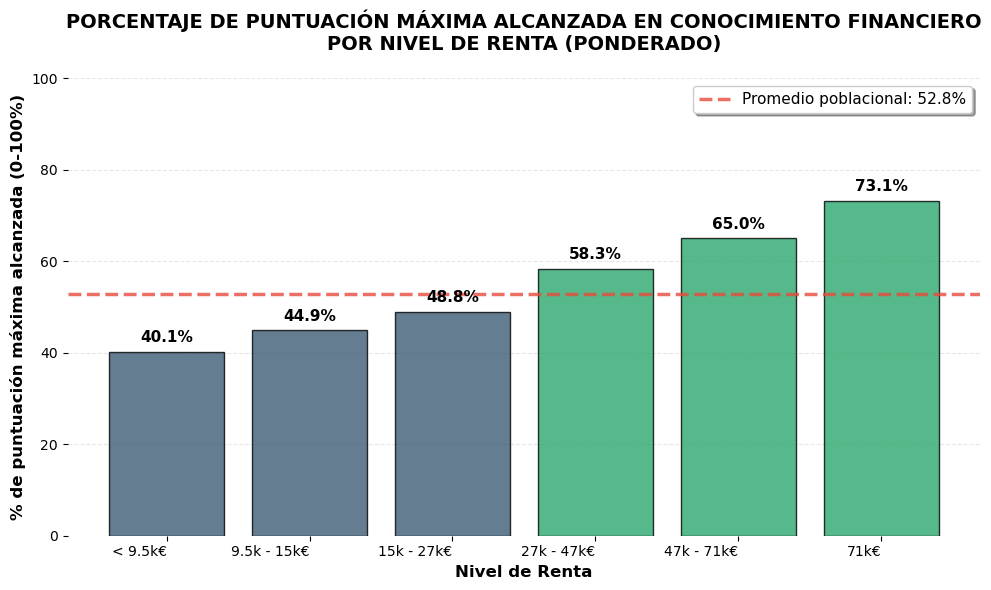


% DE PUNTUACIÓN MÁXIMA ALCANZADA POR NIVEL DE RENTA (PONDERADO)
  < 9.5k€: 40.1% (-12.6 pp vs promedio) - Score: 1.20/3
  9.5k - 15k€: 44.9% (-7.9 pp vs promedio) - Score: 1.35/3
  15k - 27k€: 48.8% (-3.9 pp vs promedio) - Score: 1.46/3
  27k - 47k€: 58.3% (+5.6 pp vs promedio) - Score: 1.75/3
  47k - 71k€: 65.0% (+12.2 pp vs promedio) - Score: 1.95/3
  71k€: 73.1% (+20.4 pp vs promedio) - Score: 2.19/3

Promedio poblacional total: 52.8% (Score: 1.58/3)


In [37]:
# ============================================================================
# GRÁFICO: % DE PUNTUACIÓN MÁXIMA ALCANZADA POR NIVEL RENTA (PONDERADO)
# ============================================================================

import matplotlib.pyplot as plt

# Calcular porcentaje ponderado de puntuación máxima (score/3*100) por nivel educativo
pct_puntuacion_max_por_renta = {}

# Usar unique() en lugar de cat.categories (funciona con cualquier tipo de dato)
for grupo in datos_limpios['renta_grupo'].dropna().unique():
    subset = datos_limpios[datos_limpios['renta_grupo'] == grupo]
    # Score medio ponderado del grupo
    score_medio = (subset['score_conocimiento'] * subset['weight']).sum() / subset['weight'].sum()
    # Convertir a porcentaje sobre la puntuación máxima (3)
    pct = (score_medio / 3) * 100
    pct_puntuacion_max_por_renta[grupo] = pct

# Calcular promedio ponderado general (línea de referencia)
score_medio_general = (datos_limpios['score_conocimiento'] * datos_limpios['weight']).sum() / datos_limpios['weight'].sum()
promedio_general_pct = (score_medio_general / 3) * 100

# Ordenar por nivel educativo (de menor a mayor)
orden_renta = ['< 9.5k€', '9.5k - 15k€', '15k - 27k€', '27k - 47k€', '47k - 71k€', '71k€']
pct_puntuacion_max_por_renta_ordenado = {k: pct_puntuacion_max_por_renta[k] for k in orden_renta if k in pct_puntuacion_max_por_renta}

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))

grupos = list(pct_puntuacion_max_por_renta_ordenado.keys())
porcentajes = list(pct_puntuacion_max_por_renta_ordenado.values())

# Barras con colores según superen o no el promedio
colores = [COLOR_VERDE if p >= promedio_general_pct else COLOR_AZUL_CLARO for p in porcentajes]

bars = ax.bar(grupos, porcentajes, color=colores, edgecolor='black', alpha=0.8, zorder=2)

# Línea del promedio general
ax.axhline(y=promedio_general_pct, color=COLOR_ROJO, linestyle='--', 
           linewidth=2.5, alpha=0.8, zorder=3, 
           label=f'Promedio poblacional: {promedio_general_pct:.1f}%')

# Etiquetas en las barras
for bar, pct in zip(bars, porcentajes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Personalización
ax.set_ylabel('% de puntuación máxima alcanzada (0-100%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nivel de Renta', fontsize=12, fontweight='bold')
ax.set_title('PORCENTAJE DE PUNTUACIÓN MÁXIMA ALCANZADA EN CONOCIMIENTO FINANCIERO\nPOR NIVEL DE RENTA (PONDERADO)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0,100)
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Rotar etiquetas si son largas
plt.xticks(rotation=0, ha='right', fontsize=10)


# Limpieza visual
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Imprimir resultados
print("\n" + "="*60)
print("% DE PUNTUACIÓN MÁXIMA ALCANZADA POR NIVEL DE RENTA (PONDERADO)")
print("="*60)
for grupo, pct in pct_puntuacion_max_por_renta_ordenado.items():
    dif = pct - promedio_general_pct
    signo = "+" if dif > 0 else ""
    # Calcular score real para referencia
    subset = datos_limpios[datos_limpios['renta_grupo'] == grupo]
    score_real = (subset['score_conocimiento'] * subset['weight']).sum() / subset['weight'].sum()
    print(f"  {grupo}: {pct:.1f}% ({signo}{dif:.1f} pp vs promedio) - Score: {score_real:.2f}/3")

print("\n" + "="*60)
print(f"Promedio poblacional total: {promedio_general_pct:.1f}% (Score: {score_medio_general:.2f}/3)")
print("="*60)

### 5. TESTS ESTADÍSTICOS (VALIDACIÓN)

 Explicación: Se aplican pruebas estadísticas para validar que las diferencias
 observadas no son producto del azar.
 - Chi-cuadrado: valida relación educación-conocimiento
 - ANOVA: valida diferencias por nivel de renta
 - T-student: confirma brecha renta alta vs baja

In [38]:
#  VALIDACIÓN ESTADÍSTICA 

# Definir función auxiliar para grupo de renta (usada en tests 2 y 3)
def grupo_renta_test(valor):
    if valor == 1: return 'Menos de 9.500€'
    elif valor == 2: return '9.501-15.000€'
    elif valor == 3: return '15.001-27.000€'
    elif valor == 4: return '27.001-47.000€'
    elif valor == 5: return '47.001-71.000€'
    elif valor == 6: return 'Más de 71.000€'
    else: return None

In [39]:
# TEST 1: CHI-CUADRADO - EDUCACIÓN vs. CONOCIMIENTO ALTO
# Propósito: Validar que la relación educación-conocimiento es significativa

print("\n" + "="*60)
print("TEST 1: Chi-cuadrado - Educación vs. Conocimiento Alto")
print("="*60)

if 'educacion_categoria' in datos_limpios.columns and 'score_conocimiento' in datos_limpios.columns:
    
    # Calcular media y crear variable binaria (conocimiento alto = por encima de la media)
    media_score = weighted_mean(datos_limpios, 'score_conocimiento')
    datos_limpios['conocimiento_alto'] = (datos_limpios['score_conocimiento'] > media_score).astype(int)
    
    # Tabla de contingencia
    tabla_educ = pd.crosstab(datos_limpios['educacion_categoria'], datos_limpios['conocimiento_alto'])
    tabla_educ = tabla_educ[tabla_educ.sum(axis=1) >= 30]  # Filtrar categorías pequeñas
    
    if len(tabla_educ) >= 2:
        print("\n Tabla de contingencia (Educación vs. Conocimiento Alto):")
        print(tabla_educ)
        
        chi2, p_chi, dof, expected = chi2_contingency(tabla_educ)
        print(f"\n Chi-cuadrado = {chi2:.4f}")
        print(f"   p-valor = {p_chi:.10f}")
        print(f"   Grados de libertad = {dof}")
        
        if p_chi < 0.05:
            print(f"\n CONCLUSIÓN: La relación EDUCACIÓN-CONOCIMIENTO es SIGNIFICATIVA")
            print(f"   → El nivel educativo SÍ determina el conocimiento financiero")
        else:
            print(f"\n No hay relación significativa")
    else:
        print("    Datos insuficientes para el test (menos de 2 categorías válidas)")
else:
    print(" Variables necesarias no encontradas: 'educacion_categoria' o 'score_conocimiento'")


TEST 1: Chi-cuadrado - Educación vs. Conocimiento Alto

 Tabla de contingencia (Educación vs. Conocimiento Alto):
conocimiento_alto               0     1
educacion_categoria                    
Bachillerato                  863  1069
Prebachillerato              1549  1031
Universitario o equivalente  1032  2220

 Chi-cuadrado = 467.0671
   p-valor = 0.0000000000
   Grados de libertad = 2

 CONCLUSIÓN: La relación EDUCACIÓN-CONOCIMIENTO es SIGNIFICATIVA
   → El nivel educativo SÍ determina el conocimiento financiero


In [40]:
# TEST 2: ANOVA - RENTA vs. CONOCIMIENTO
# Propósito: Validar que existen diferencias significativas entre niveles de renta


print("\n" + "="*60)
print("TEST 2: ANOVA - Renta vs. Conocimiento")
print("="*60)

if 'j1300' in datos_limpios.columns:
    
    # Preparar datos (limpiar valores negativos)
    renta_limpia = datos_limpios[datos_limpios['j1300'] >= 0].copy()
    renta_limpia['renta_grupo'] = renta_limpia['j1300'].apply(grupo_renta_test)
    
    # Grupos para ANOVA
    grupos = []
    for grupo in renta_limpia['renta_grupo'].dropna().unique():
        scores = renta_limpia[renta_limpia['renta_grupo'] == grupo]['score_conocimiento'].dropna()
        if len(scores) > 0:
            grupos.append(scores)
            print(f"   Grupo '{grupo}': {len(scores)} personas")
    
    if len(grupos) >= 2:
        f_stat, p_anova = f_oneway(*grupos)
        print(f"\n ANOVA: F-statistic = {f_stat:.4f}")
        print(f"   p-valor = {p_anova:.10f}")
        
        if p_anova < 0.05:
            print(f"\n CONCLUSIÓN: Las diferencias por RENTA son SIGNIFICATIVAS")
            print(f"   → A mayor nivel de ingresos, mayor conocimiento financiero")
        else:
            print(f"\n No hay diferencias significativas por renta")
    else:
        print("    Datos insuficientes para ANOVA (menos de 2 grupos con datos válidos)")
else:
    print("❌ Variable 'j1300' no encontrada")


TEST 2: ANOVA - Renta vs. Conocimiento
   Grupo '27.001-47.000€': 2116 personas
   Grupo '9.501-15.000€': 1149 personas
   Grupo 'Más de 71.000€': 520 personas
   Grupo '15.001-27.000€': 1944 personas
   Grupo '47.001-71.000€': 990 personas
   Grupo 'Menos de 9.500€': 563 personas

 ANOVA: F-statistic = 121.0434
   p-valor = 0.0000000000

 CONCLUSIÓN: Las diferencias por RENTA son SIGNIFICATIVAS
   → A mayor nivel de ingresos, mayor conocimiento financiero


In [41]:
# TEST 3: T-STUDENT - RENTA ALTA (>71k€) vs. RENTA BAJA (<9.5k€)
# Propósito: Confirmar que la brecha entre los extremos es significativa

print("\n" + "="*60)
print("TEST 3: T-student - Renta Alta (>71k€) vs. Renta Baja (<9.5k€)")
print("="*60)

if 'j1300' in datos_limpios.columns:
    
    # Extraer grupos extremos
    renta_alta = datos_limpios[datos_limpios['j1300'] == 6]['score_conocimiento'].dropna()
    renta_baja = datos_limpios[datos_limpios['j1300'] == 1]['score_conocimiento'].dropna()
    
    if len(renta_alta) > 0 and len(renta_baja) > 0:
        
        # Calcular estadísticos
        media_alta = renta_alta.mean()
        media_baja = renta_baja.mean()
        n_alta = len(renta_alta)
        n_baja = len(renta_baja)
        
        # T-test
        t_stat, p_ttest = ttest_ind(renta_alta, renta_baja)
        
        print(f"\n Renta Alta (>71k€): {media_alta:.3f} puntos (n={n_alta})")
        print(f"   Renta Baja (<9.5k€): {media_baja:.3f} puntos (n={n_baja})")
        print(f"   Diferencia: {media_alta - media_baja:.3f} puntos")
        print(f"\n t-statistic = {t_stat:.4f}")
        print(f"   p-valor = {p_ttest:.10f}")
        
        if p_ttest < 0.05:
            print(f"\n CONCLUSIÓN: La diferencia entre renta alta y baja es SIGNIFICATIVA")
            print(f"   → La brecha de conocimiento por ingresos es REAL")
        else:
            print(f"\n La diferencia no es significativa")
    else:
        print("    Datos insuficientes para t-test")
        if len(renta_alta) == 0:
            print("      - No hay datos para renta alta (>71k€)")
        if len(renta_baja) == 0:
            print("      - No hay datos para renta baja (<9.5k€)")
else:
    print(" Variable 'j1300' no encontrada")


TEST 3: T-student - Renta Alta (>71k€) vs. Renta Baja (<9.5k€)

 Renta Alta (>71k€): 2.177 puntos (n=520)
   Renta Baja (<9.5k€): 1.233 puntos (n=563)
   Diferencia: 0.944 puntos

 t-statistic = 17.9988
   p-valor = 0.0000000000

 CONCLUSIÓN: La diferencia entre renta alta y baja es SIGNIFICATIVA
   → La brecha de conocimiento por ingresos es REAL


In [42]:
# RESUMEN DE VALIDACIÓN ESTADÍSTICA

print("\n" + "="*60)
print(" RESUMEN DE VALIDACIÓN ESTADÍSTICA")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│                         VEREDICTO ESTADÍSTICO                           │
└─────────────────────────────────────────────────────────────────────────┘

 Chi-cuadrado:    EDUCACIÓN → CONOCIMIENTO (relación válida, p<0.001)
 ANOVA:           RENTA → CONOCIMIENTO (diferencias reales, p<0.001)  
 T-student:       BRECHA RENTA ALTA/BAJA (diferencia significativa, p<0.001)

 Las diferencias observadas NO son por azar.
 Las conclusiones son ESTADÍSTICAMENTE VÁLIDAS.
""")


 RESUMEN DE VALIDACIÓN ESTADÍSTICA

┌─────────────────────────────────────────────────────────────────────────┐
│                         VEREDICTO ESTADÍSTICO                           │
└─────────────────────────────────────────────────────────────────────────┘

 Chi-cuadrado:    EDUCACIÓN → CONOCIMIENTO (relación válida, p<0.001)
 ANOVA:           RENTA → CONOCIMIENTO (diferencias reales, p<0.001)  
 T-student:       BRECHA RENTA ALTA/BAJA (diferencia significativa, p<0.001)

 Las diferencias observadas NO son por azar.
 Las conclusiones son ESTADÍSTICAMENTE VÁLIDAS.



## CONOCIMIENTO DE PRODUCTOS FINANCIEROS

In [43]:
conceptos_prod = {
    'k1901': '¿HA OÍDO HABLAR DE LAS HIPOTECAS?',
    'k1902': '¿HA OÍDO HABLAR DE LOS PLANES DE PENSIONES INDIVIDUALES O DE EMPRESA?',
    'k1903': '¿HA OÍDO HABLAR DE LOS FONDOS DE INVERSIÓN?',
    'k1904': '¿HA OÍDO HABLAR DE LAS ACCIONES?',
    'k1905': '¿HA OÍDO HABLAR DE LOS ACTIVOS DE RENTA FIJA PÚBLICA O PRIVADA, COMO POR EJEMPLO BONOS O LETRAS DEL TESORO?',
    'k1906': '¿HA OÍDO HABLAR DE LOS PRÉSTAMOS PERSONALES?',
    'k1907': '¿HA OÍDO HABLAR DE LAS TARJETAS DE CRÉDITO?',
    'k1908': '¿HA OÍDO HABLAR DE LAS CUENTAS O DEPÓSITOS DE AHORRO O A PLAZO, O A LA VISTA QUE NO PUEDEN SER UTILIZADOS PARA REALIZAR PAGOS MEDIANTE TARJETAS O CHEQUES?',
    'k1909': '¿HA OÍDO HABLAR DE LOS SEGUROS DE VIDA?',
    'k1910': '¿HA OÍDO HABLAR DE LOS SEGUROS MÉDICOS?',
    'k1912': '¿HA OÍDO HABLAR DE LAS CRIPTOMONEDAS (POR EJEMPLO, BITCOIN)?',

}

conceptos_prod_etiq = {
    'k1901': 'Hipoteca',
    'k1902': 'Plan De Pensiones',
    'k1903': 'Fondo De Inversión',
    'k1904': 'Acciones',
    'k1905': 'Renta Fija',
    'k1906': 'Préstamo Personal',
    'k1907': 'Tarjeta De Crédito',
    'k1908': 'Cuenta De Ahorro',
    'k1909': 'Seguro De Vida',
    'k1910': 'Seguro Médico',
    'k1912': 'Criptomonedas',

}


### Análisis por **grupos de edad** teniendo en cuenta **weight** de registro

In [44]:
df_prod = datos_limpios[list(conceptos_prod.keys()) + ['grupo_edad', 'nivel_educativo_detalle', 'educacion_categoria', 'weight', 'j1300']]
df_prod.rename(columns=conceptos_prod_etiq, inplace=True)
df_prod.head(3)

C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\3456206239.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prod.rename(columns=conceptos_prod_etiq, inplace=True)


,Hipoteca,Plan De Pensiones,Fondo De Inversión,Acciones,Renta Fija,Préstamo Personal,Tarjeta De Crédito,Cuenta De Ahorro,Seguro De Vida,Seguro Médico,Criptomonedas,grupo_edad,nivel_educativo_detalle,educacion_categoria,weight,j1300
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35-44,Diplomatura/Grado universitario,Universitario o equivalente,6814.1260,4.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45-54,Licenciatura/Máster,Universitario o equivalente,3277.0151,4.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45-54,Secundaria (2ª etapa) - Bachillerato/FP Grado ...,Bachillerato,1730.8894,4.0


In [45]:
def media_ponderada_por_grupo(
    df,
    columna_valor,
    columna_grupo='grupo_edad',
    columna_peso='weight'
):
    """
    Calcula la media ponderada por grupo.

    Parámetros:
    -----------
    df : DataFrame
    columna_valor : str
        Columna numérica a analizar.
    columna_grupo : str
        Columna para agrupar.
    columna_peso : str
        Columna de pesos.

    Retorna:
    --------
    Series con media ponderada por grupo.
    """

    def calcular_media(g):
        datos = g[[columna_valor, columna_peso]].dropna()

        if len(datos) == 0:
            return np.nan

        return np.average(
            datos[columna_valor],
            weights=datos[columna_peso]
        )

    return df.groupby(columna_grupo).apply(calcular_media)


In [46]:
resultado = {}
columnas_prod = list(conceptos_prod_etiq.values())

for col in columnas_prod:
    resultado[col] = media_ponderada_por_grupo(
        df_prod,
        columna_valor=col
    )

df_resultado = pd.DataFrame(resultado)

df_resultado

C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(columna_grupo).apply(calcular_media)
C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(columna_grupo).apply(calcular_media)
C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of

,Hipoteca,Plan De Pensiones,Fondo De Inversión,Acciones,Renta Fija,Préstamo Personal,Tarjeta De Crédito,Cuenta De Ahorro,Seguro De Vida,Seguro Médico,Criptomonedas
grupo_edad,,,,,,,,,,,
18-34,0.981590,0.937458,0.922360,0.926494,0.821291,0.974774,0.982379,0.644286,0.983677,0.978825,0.868235
35-44,0.974335,0.951849,0.928608,0.931866,0.855335,0.976759,0.971250,0.720410,0.965597,0.971250,0.870957
45-54,1.000000,0.942824,0.932756,0.920797,0.868348,0.985860,0.993349,0.675908,0.993349,0.981667,0.872592
55-64,0.987225,0.967283,0.937303,0.937513,0.872990,0.991570,1.000000,0.640896,0.991148,0.985853,0.873244
65+,0.988374,0.964097,0.952385,0.946732,0.833646,0.972640,1.000000,0.654867,0.997181,0.993483,0.756332


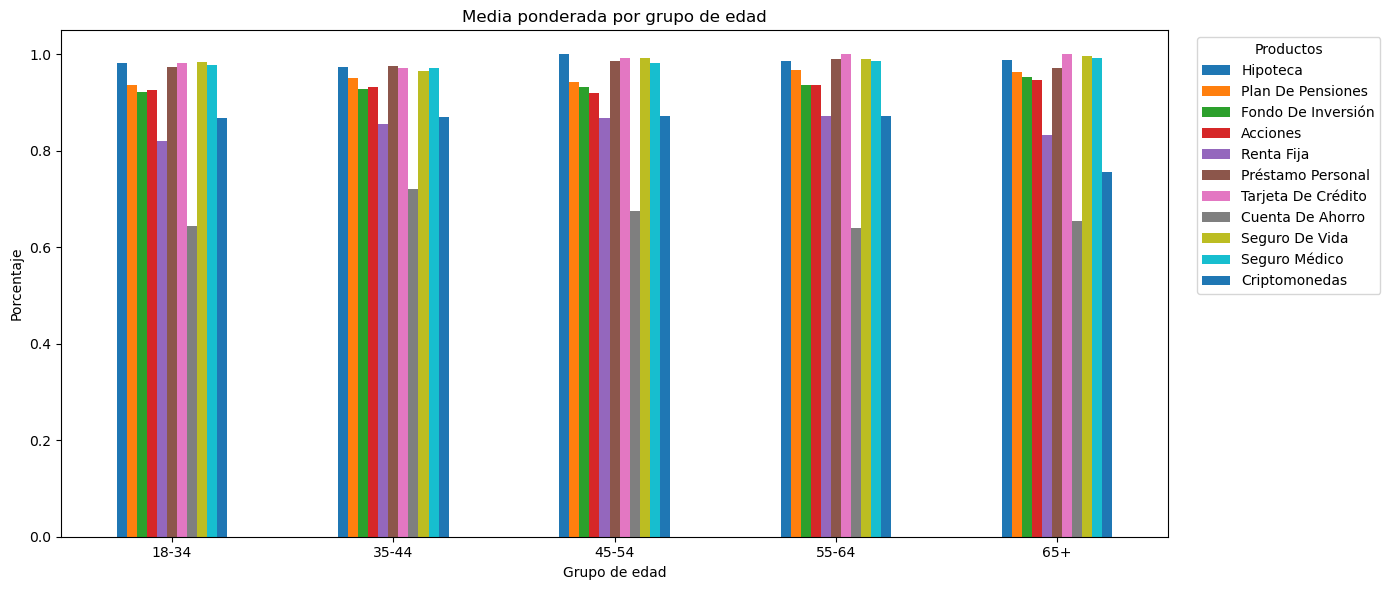

In [47]:
# Crear gráfico
df_resultado.plot(
    kind='bar',
    figsize=(14, 6)
)

# Personalización
plt.title('Media ponderada por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Productos', bbox_to_anchor=(1.02, 1), loc='upper left')

# Ajustar layout
plt.tight_layout()

# Mostrar
plt.show()

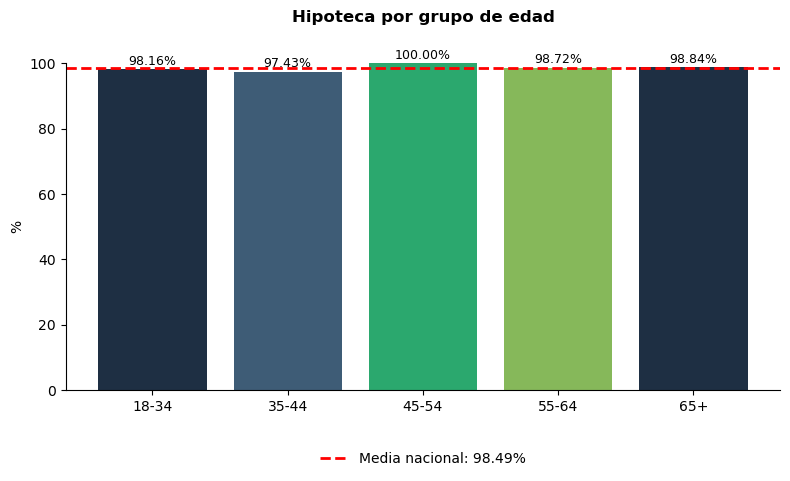

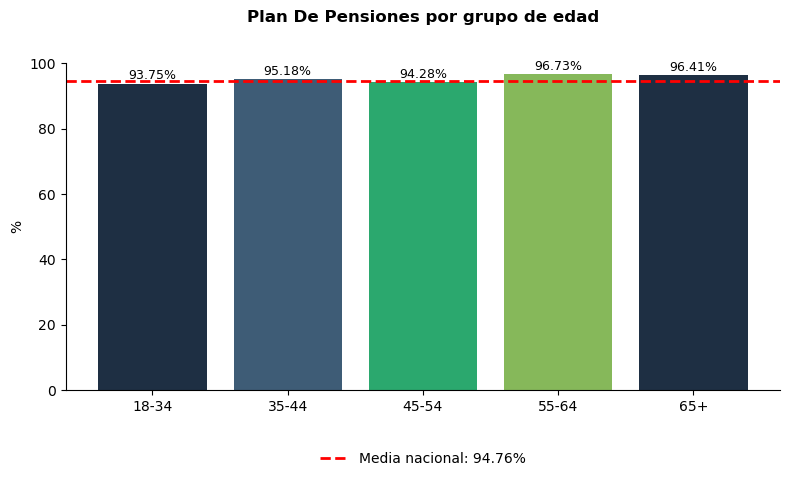

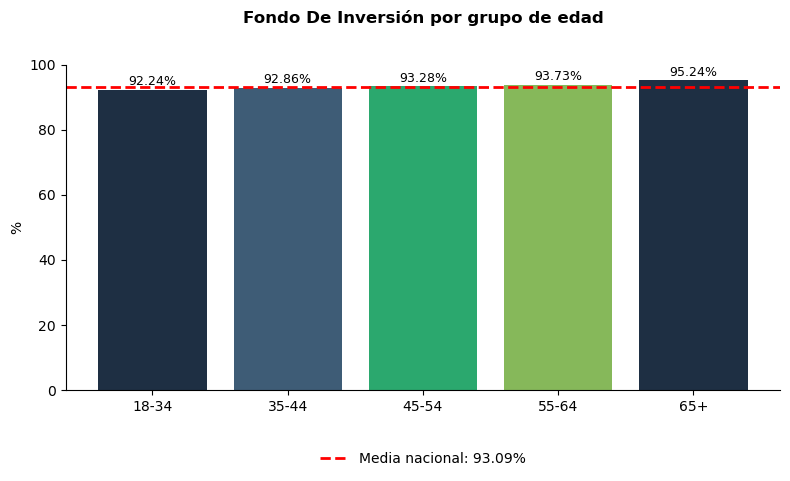

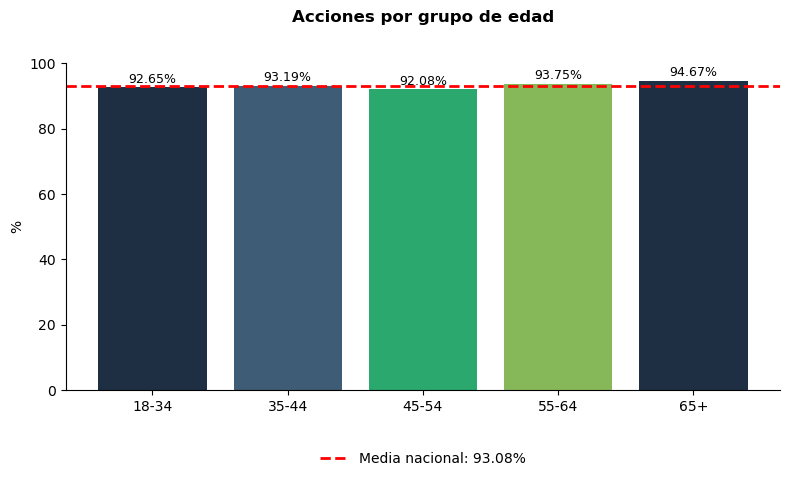

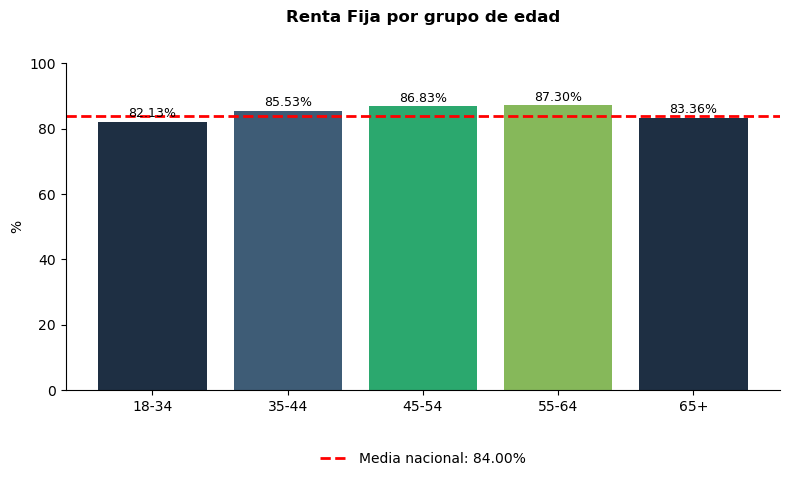

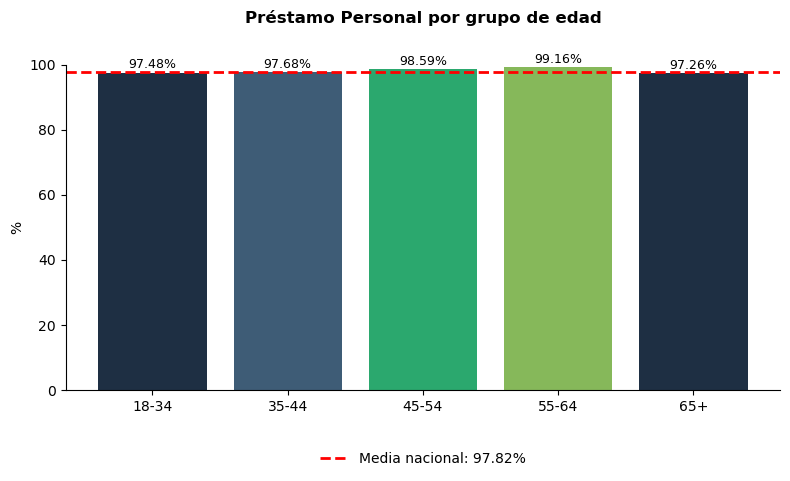

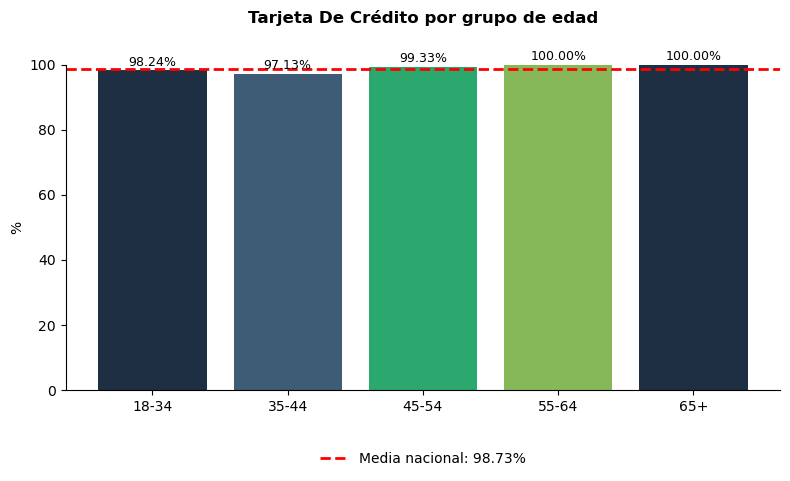

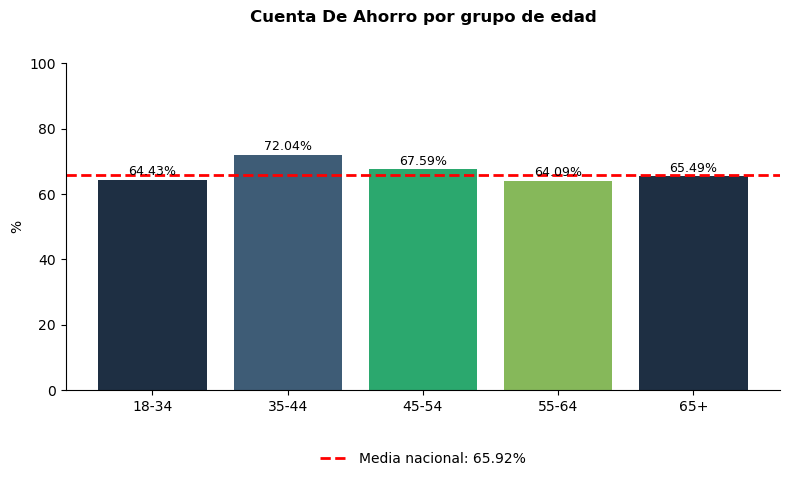

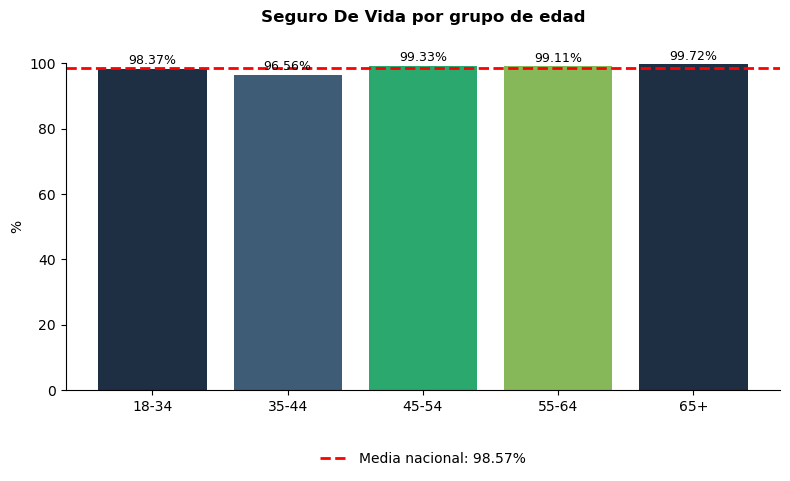

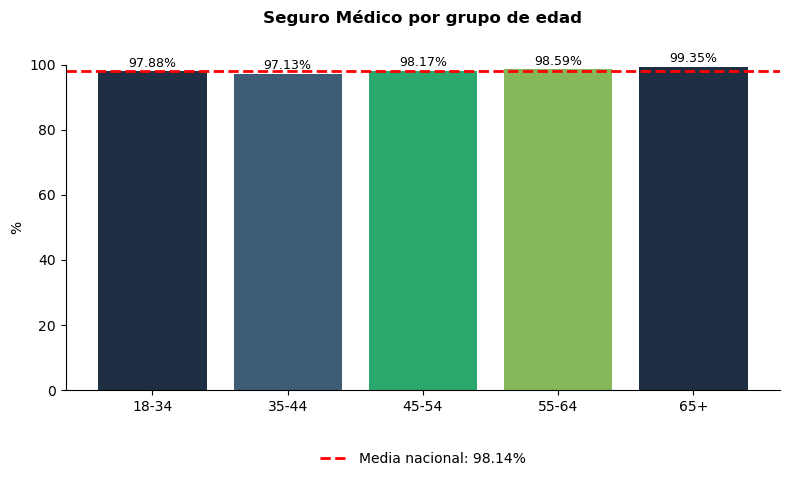

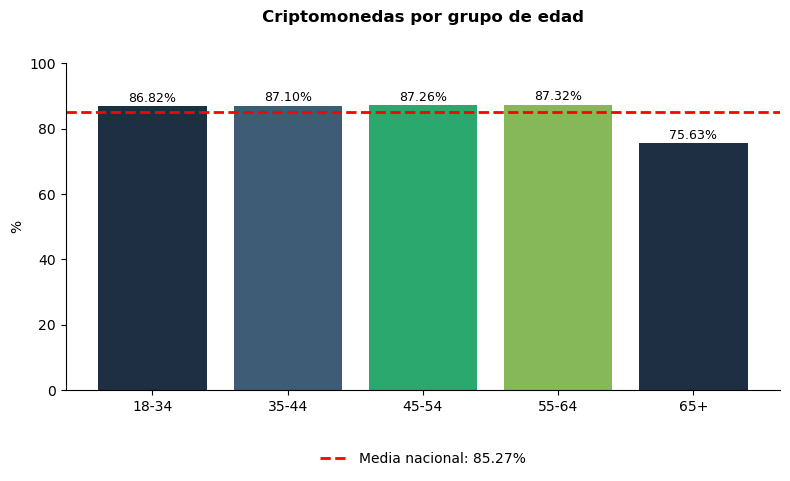

In [48]:
# Convertir a porcentaje
df_pct = df_resultado * 100

for col in df_pct.columns:

    fig, ax = plt.subplots(figsize=(8, 5))

    valores = df_pct[col]

    barras = ax.bar(
        valores.index,
        valores.values,
        color=[COLOR_AZUL, COLOR_AZUL_CLARO, COLOR_VERDE, COLOR_VERDE_CLARO, COLOR_AZUL]
    )

   # ==========================
    # MEDIA PONDERADA TOTAL
    # ==========================

    datos_total = df_prod[[col, 'weight']].dropna()

    media_total = (
        np.average(
            datos_total[col],
            weights=datos_total['weight']
        ) * 100
    )

    # Línea roja
    ax.axhline(
        y=media_total,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Media nacional: {media_total:.2f}%'
    )


    # Valores encima de barras
    for barra in barras:

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width()/2,
            altura + 0.5,
            f'{altura:.2f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Zoom eje Y
    ax.set_ylim(0, 100)

    # Quitar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Opcional: quitar cuadrícula
    ax.grid(False)

    # Títulos
    ax.set_title(f'{col} por grupo de edad', pad=30, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('%')

    # Leyenda debajo del gráfico
    ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False)

    plt.tight_layout()

    plt.show()

### Análisis por **nivel educativo** teniendo en cuenta **weight** de registro

In [49]:
resultado = {}
columnas_prod = list(conceptos_prod_etiq.values())

for col in columnas_prod:
    resultado[col] = media_ponderada_por_grupo(
        df_prod,
        columna_valor=col,
        columna_grupo='educacion_categoria'
    )

df_resultado = pd.DataFrame(resultado)

orden = ['Prebachillerato', 'Bachillerato', 'Universitario o equivalente']

df_resultado = df_resultado.reindex(orden)

df_resultado

C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(columna_grupo).apply(calcular_media)
C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(columna_grupo).apply(calcular_media)
C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarni

,Hipoteca,Plan De Pensiones,Fondo De Inversión,Acciones,Renta Fija,Préstamo Personal,Tarjeta De Crédito,Cuenta De Ahorro,Seguro De Vida,Seguro Médico,Criptomonedas
educacion_categoria,,,,,,,,,,,
Prebachillerato,0.982158,0.934561,0.907012,0.900135,0.777556,0.972178,0.989183,0.627141,0.988438,0.979333,0.763524
Bachillerato,0.984390,0.947062,0.938289,0.944273,0.850561,0.980792,0.982654,0.654449,0.981209,0.978701,0.894608
Universitario o equivalente,0.989419,0.967243,0.957949,0.961273,0.919847,0.984364,0.989402,0.710791,0.986406,0.987043,0.938679


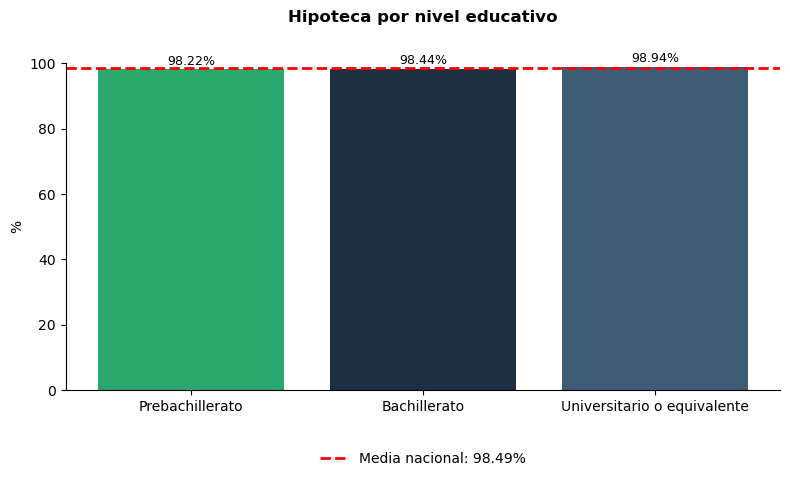

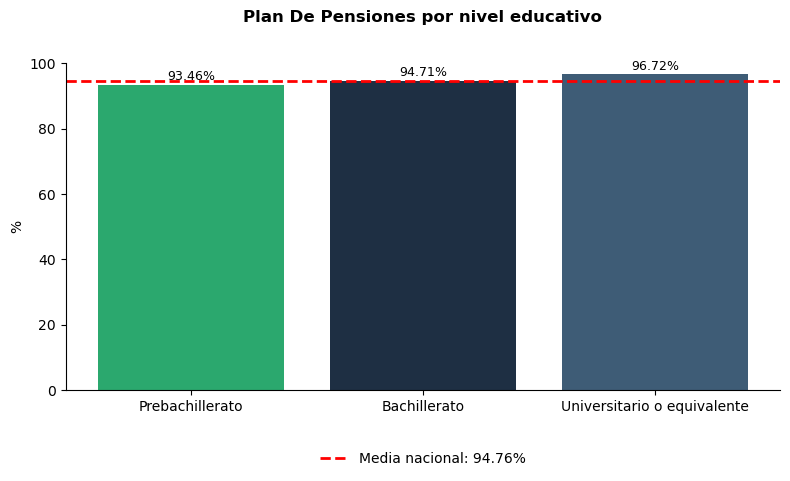

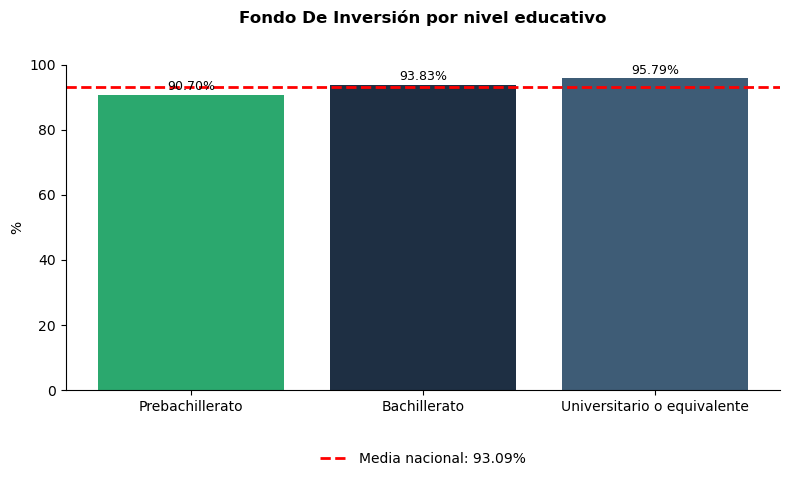

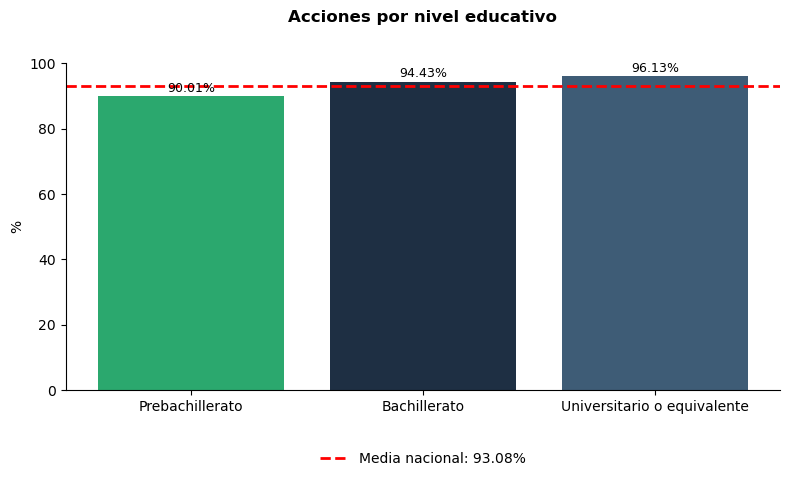

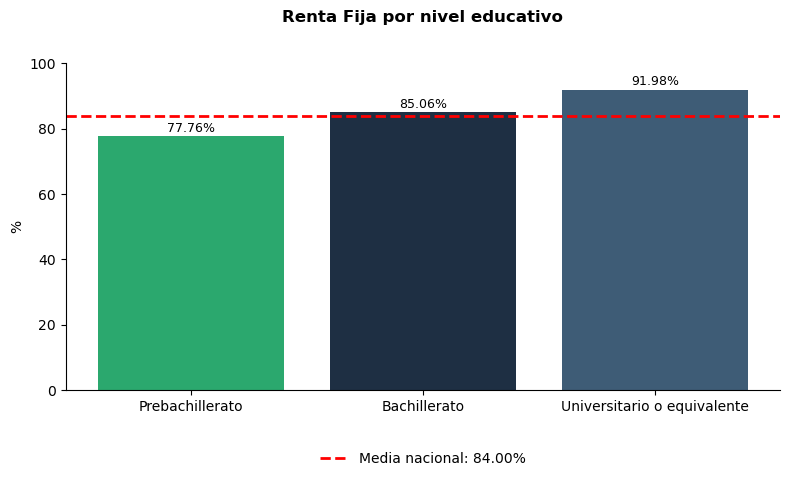

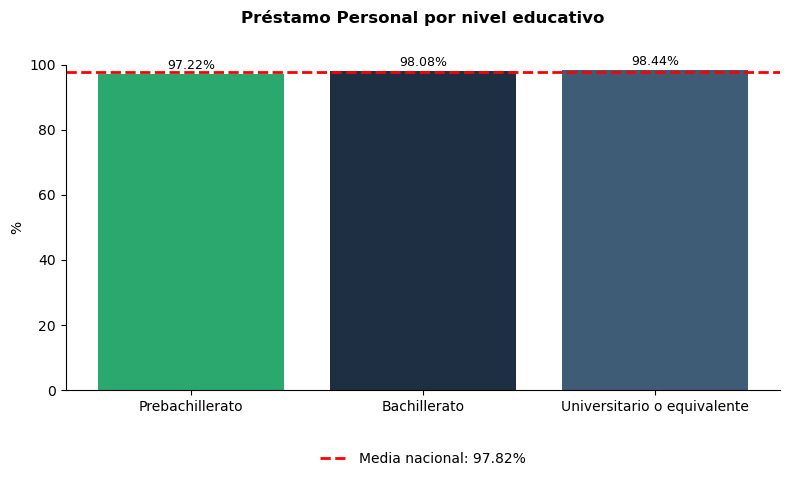

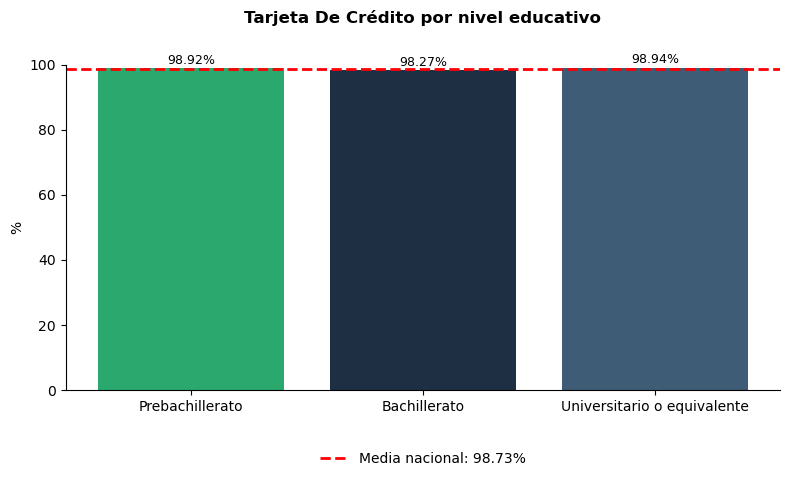

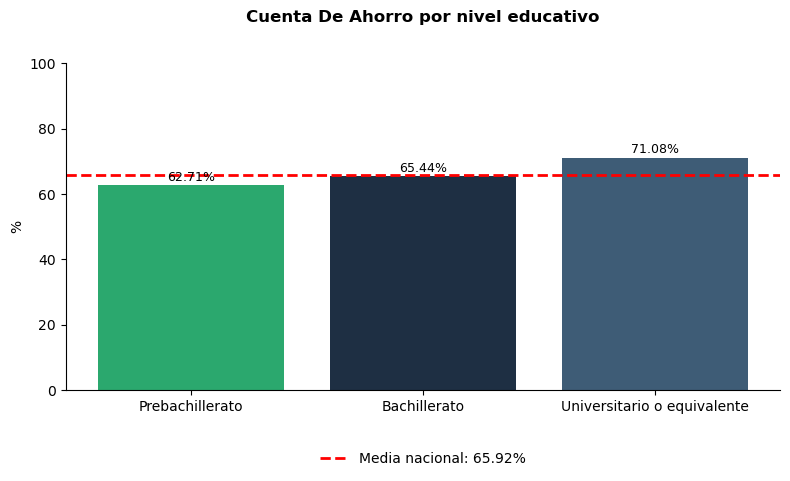

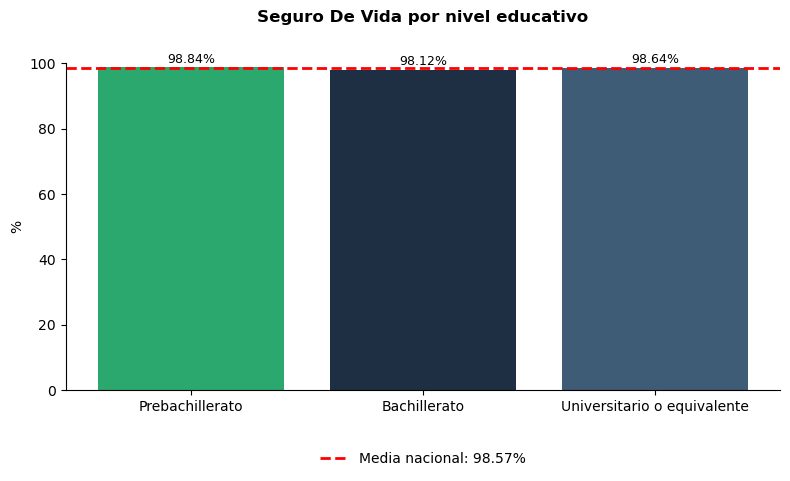

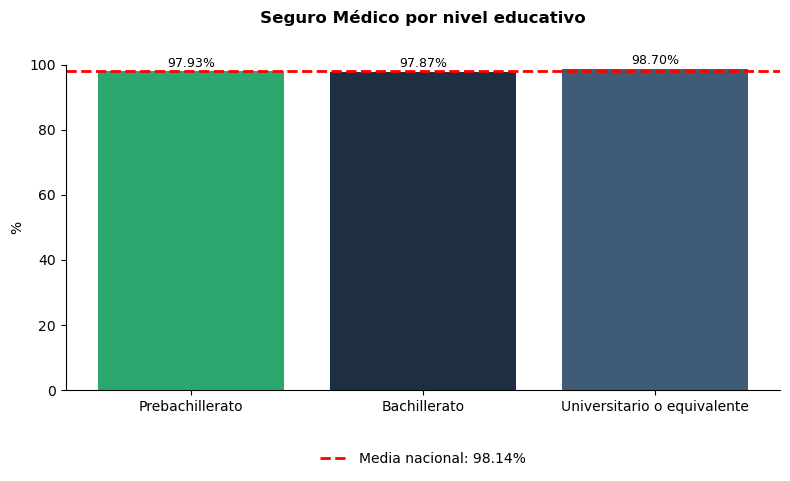

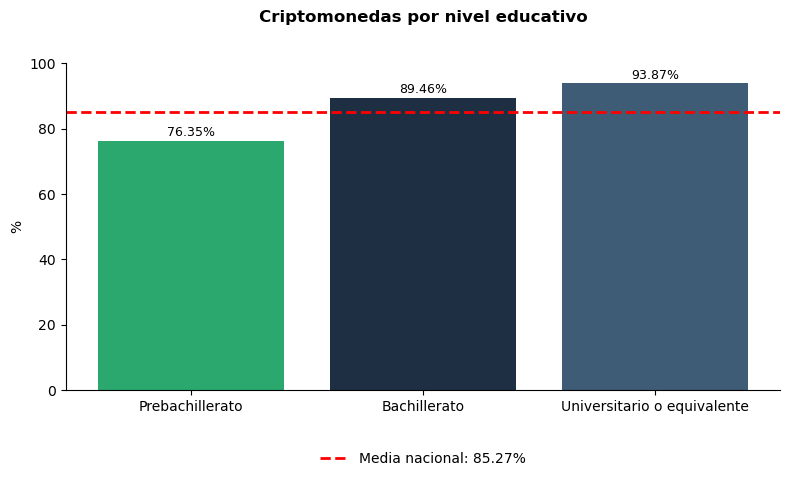

In [50]:
# Convertir a porcentaje
df_pct = df_resultado * 100

for col in df_pct.columns:

    fig, ax = plt.subplots(figsize=(8, 5))

    valores = df_pct[col]

    barras = ax.bar(
        valores.index,
        valores.values,
        color=[COLOR_VERDE, COLOR_AZUL, COLOR_AZUL_CLARO]
    )

   # ==========================
    # MEDIA PONDERADA TOTAL
    # ==========================

    datos_total = df_prod[[col, 'weight']].dropna()

    media_total = (
        np.average(
            datos_total[col],
            weights=datos_total['weight']
        ) * 100
    )

    # Línea roja
    ax.axhline(
        y=media_total,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Media nacional: {media_total:.2f}%'
    )


    # Valores encima de barras
    for barra in barras:

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width()/2,
            altura + 0.5,
            f'{altura:.2f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Zoom eje Y
    ax.set_ylim(0, 100)

    # Quitar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Opcional: quitar cuadrícula
    ax.grid(False)

    # Títulos
    ax.set_title(f'{col} por nivel educativo', pad=30, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('%')

    # Leyenda debajo del gráfico
    ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False)

    plt.tight_layout()

    plt.show()

### Análisis por por **nivel de renta** (usando j1300) teniendo en cuenta **weight** de registro

In [51]:
def grupo_renta(valor):

        if valor == 1:
            return '< 9.5k€'
        elif valor == 2:
            return '9.5k - 15k€'
        elif valor == 3:
            return '15k - 27k€'
        elif valor == 4:
            return '27k - 47k€'
        elif valor == 5:
            return '47k - 71k€'
        elif valor == 6:
            return '71k€'
        else:
            return None

In [52]:
# Creamos la variable grupo_renta para hacer la visualizacion

df_prod['grupo_renta'] = df_prod['j1300'].apply(grupo_renta)
df_prod['grupo_renta'].value_counts(dropna=False)

C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1033161008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prod['grupo_renta'] = df_prod['j1300'].apply(grupo_renta)


grupo_renta
27k - 47k€     2116
15k - 27k€     1944
9.5k - 15k€    1149
47k - 71k€      990
< 9.5k€         563
71k€            520
None            482
Name: count, dtype: int64

In [53]:
resultado = {}
columnas_prod = list(conceptos_prod_etiq.values())

for col in columnas_prod:
    resultado[col] = media_ponderada_por_grupo(
        df_prod,
        columna_valor=col,
        columna_grupo='grupo_renta'
    )

df_resultado = pd.DataFrame(resultado)

df_resultado = df_resultado.reindex(orden_renta)

df_resultado

C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(columna_grupo).apply(calcular_media)
C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(columna_grupo).apply(calcular_media)
C:\Users\Margot\AppData\Local\Temp\ipykernel_15772\1428071467.py:36: FutureWarni

,Hipoteca,Plan De Pensiones,Fondo De Inversión,Acciones,Renta Fija,Préstamo Personal,Tarjeta De Crédito,Cuenta De Ahorro,Seguro De Vida,Seguro Médico,Criptomonedas
grupo_renta,,,,,,,,,,,
< 9.5k€,0.959655,0.833031,0.725001,0.748681,0.551170,0.875427,0.945963,0.395964,0.955544,0.910908,0.558949
9.5k - 15k€,0.997078,0.929674,0.934692,0.910278,0.735931,0.991804,0.995307,0.604990,0.988963,0.983814,0.747720
15k - 27k€,0.959671,0.927278,0.913710,0.910628,0.831304,0.966400,0.976960,0.623953,0.975584,0.979250,0.832017
27k - 47k€,1.000000,0.978872,0.969887,0.967943,0.902813,0.994359,0.996492,0.731618,0.995070,0.992685,0.936596
47k - 71k€,0.998979,0.990083,0.984722,0.991211,0.955978,0.995700,0.998979,0.730996,0.993963,0.998496,0.963723
71k€,0.977144,0.977144,0.961440,0.969822,0.941233,0.977144,0.977144,0.796189,0.977144,0.977144,0.970579


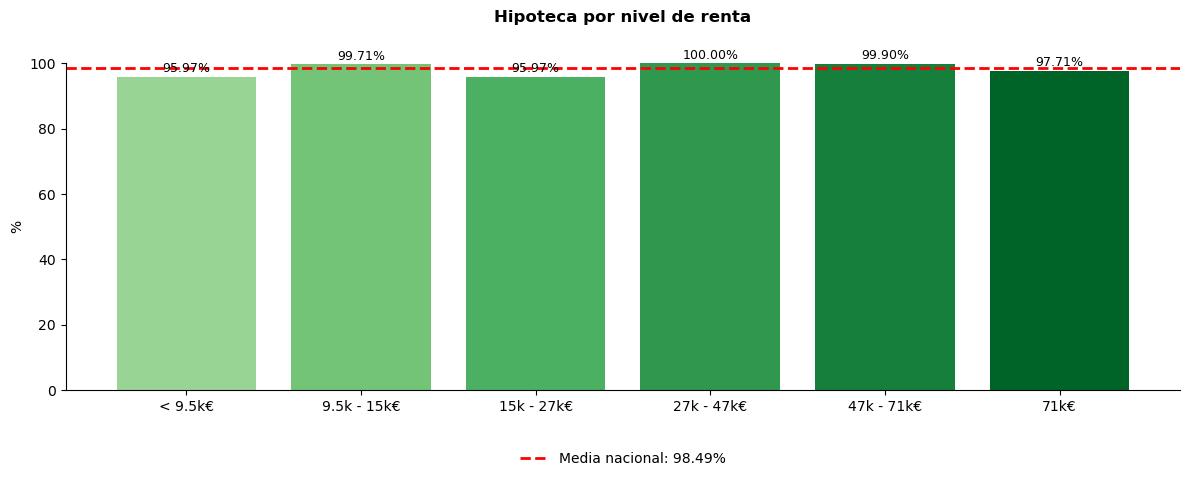

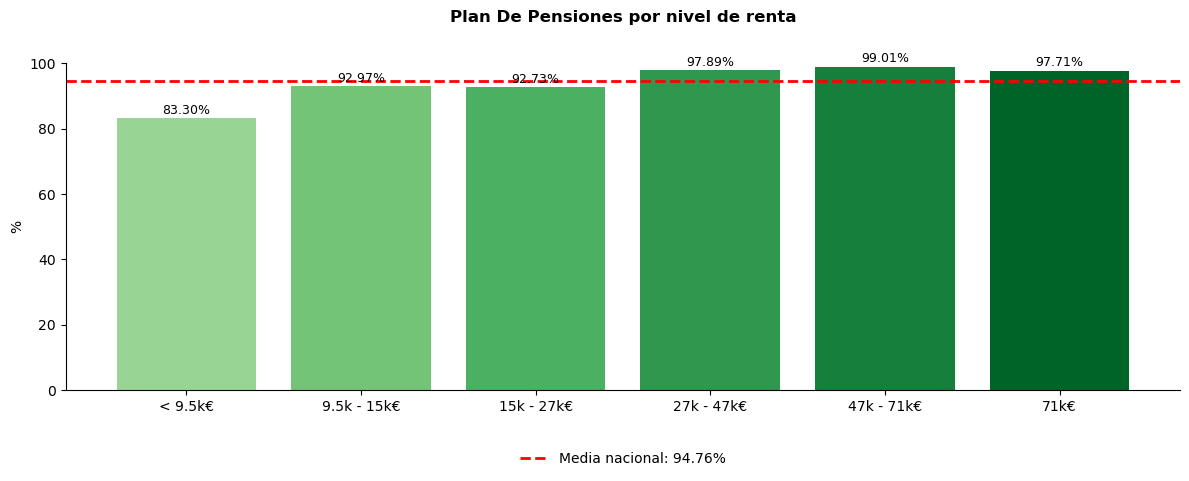

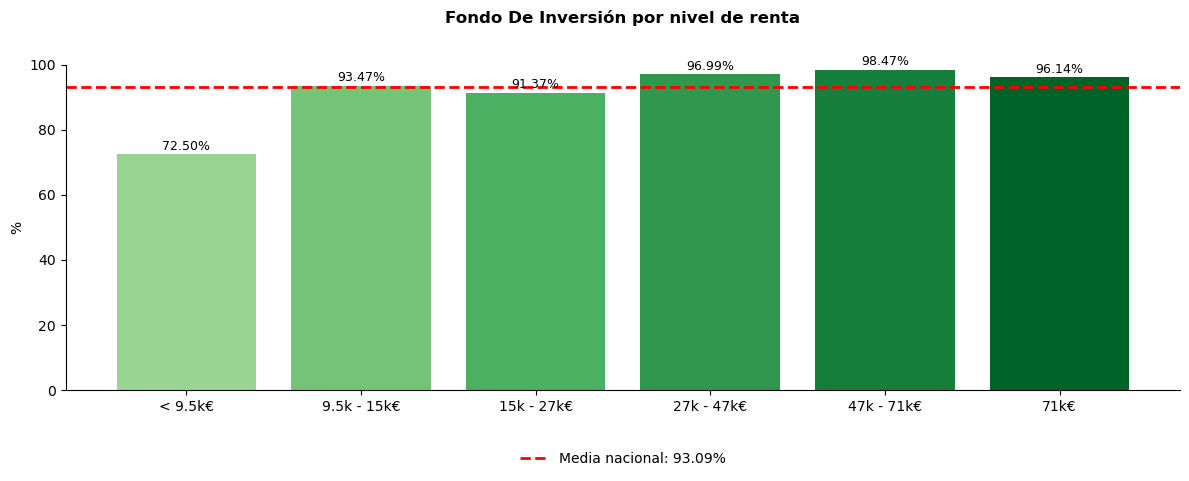

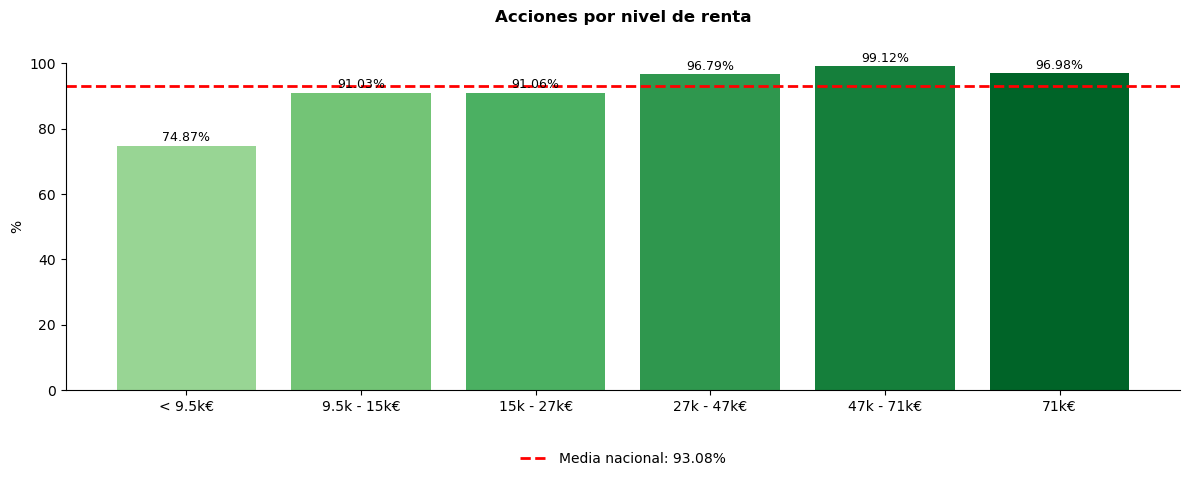

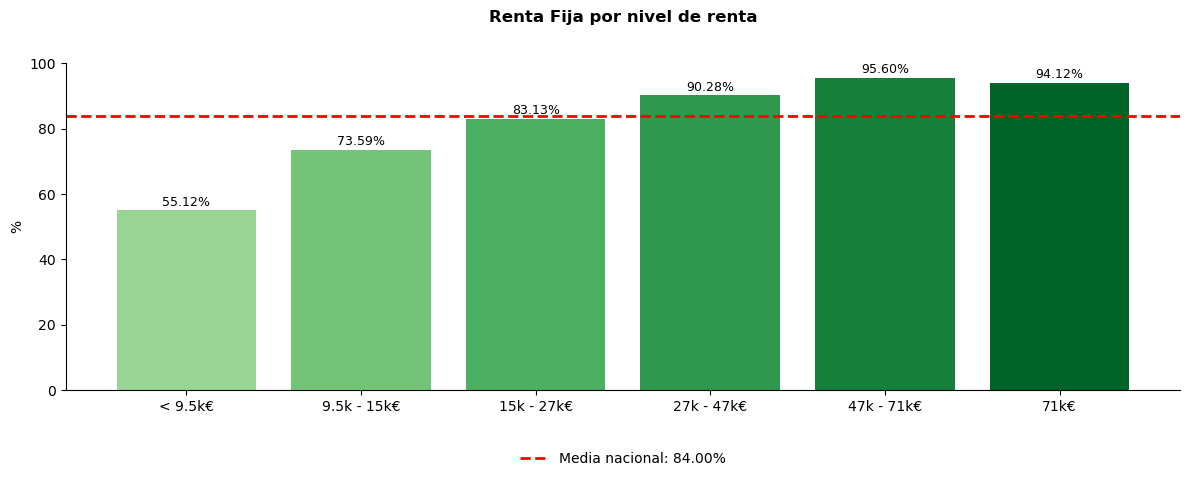

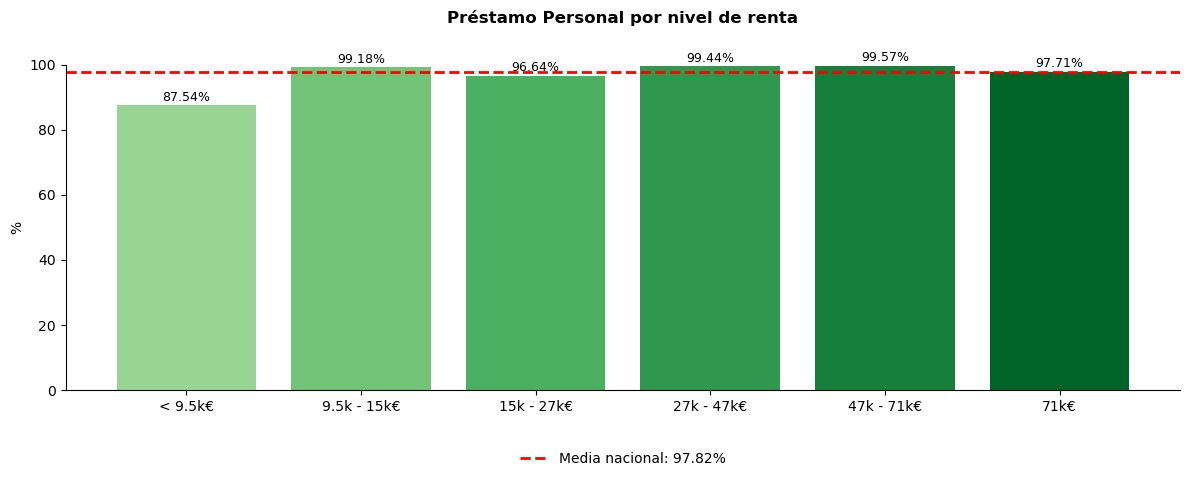

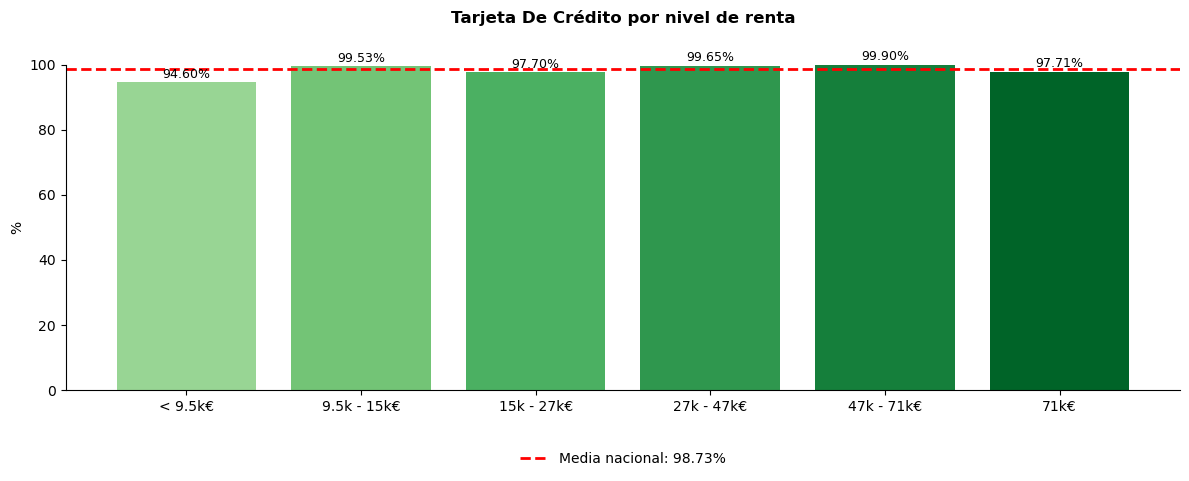

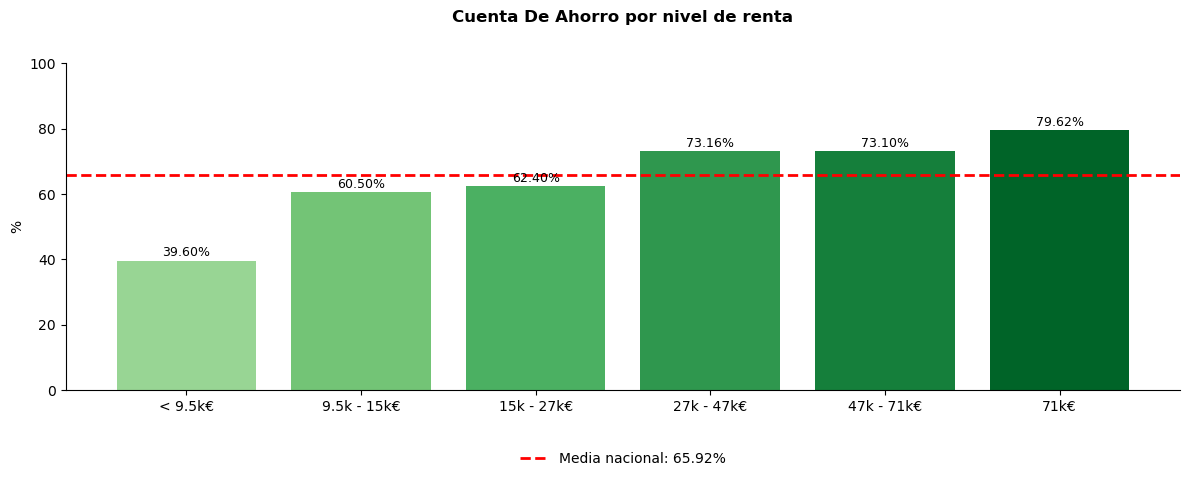

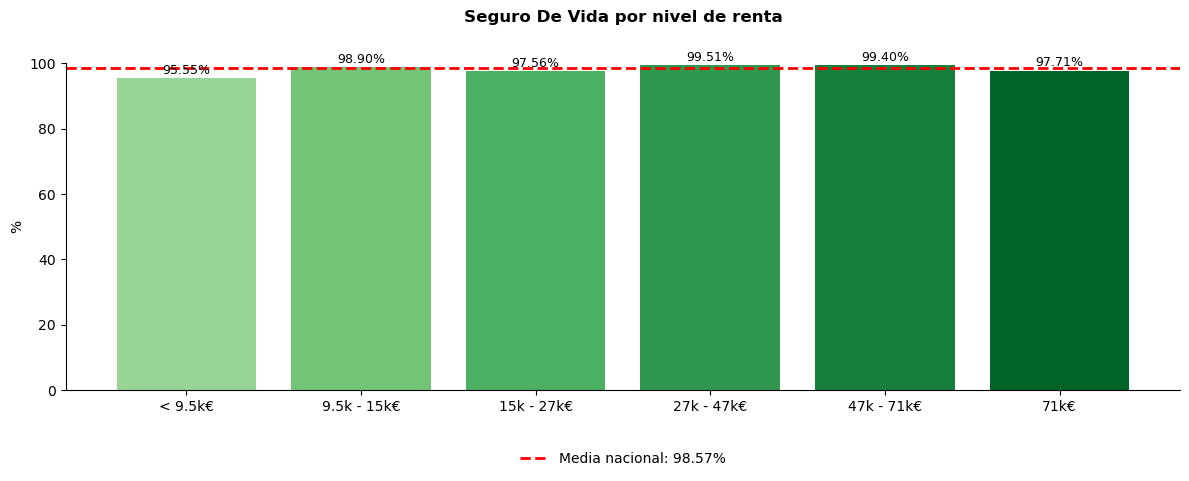

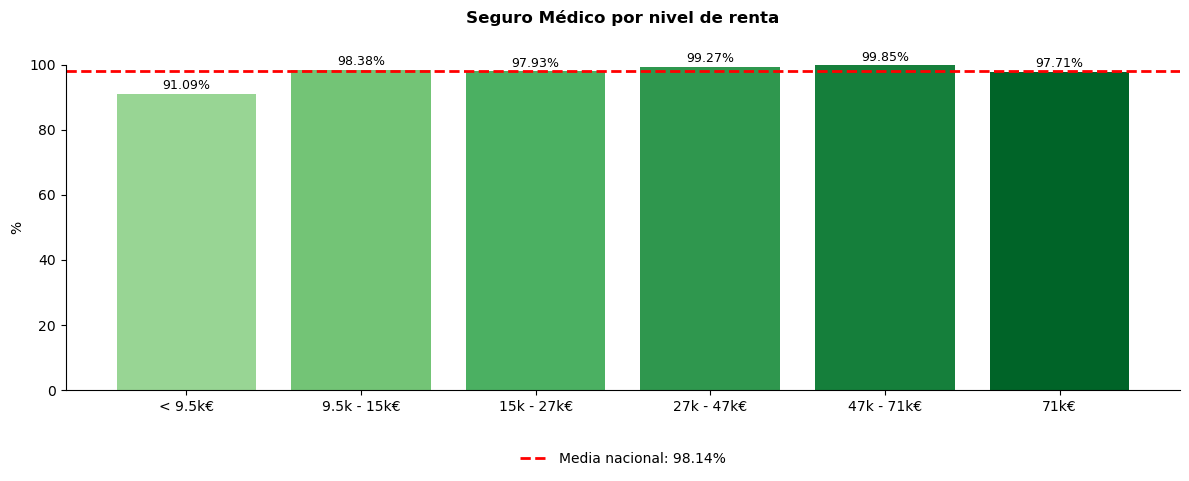

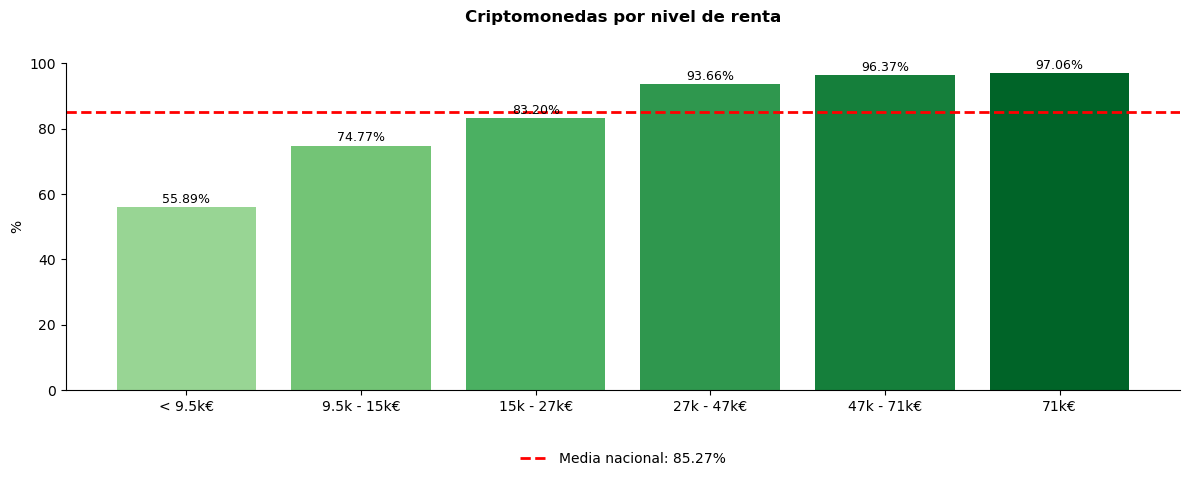

In [54]:
# Convertir a porcentaje
df_pct = df_resultado * 100



for col in df_pct.columns:

    fig, ax = plt.subplots(figsize=(12, 5))

    valores = df_pct[col]

    barras = ax.bar(
        valores.index,
        valores.values,
        color=plt.cm.Greens(np.linspace(0.4, 0.9, len(grupos_vis)))
    )

   # ==========================
    # MEDIA PONDERADA TOTAL
    # ==========================

    datos_total = df_prod[[col, 'weight']].dropna()

    media_total = (
        np.average(
            datos_total[col],
            weights=datos_total['weight']
        ) * 100
    )

    # Línea roja
    ax.axhline(
        y=media_total,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Media nacional: {media_total:.2f}%'
    )


    # Valores encima de barras
    for barra in barras:

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width()/2,
            altura + 0.5,
            f'{altura:.2f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Zoom eje Y
    ax.set_ylim(0, 100)

    # Quitar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Opcional: quitar cuadrícula
    ax.grid(False)

    # Títulos
    ax.set_title(f'{col} por nivel de renta', pad=30, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('%')

    # Leyenda debajo del gráfico
    ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False)

    plt.tight_layout()

    plt.show()

# VISUALIZACIÖN COMPLEMENTARIA - PRESENTACION

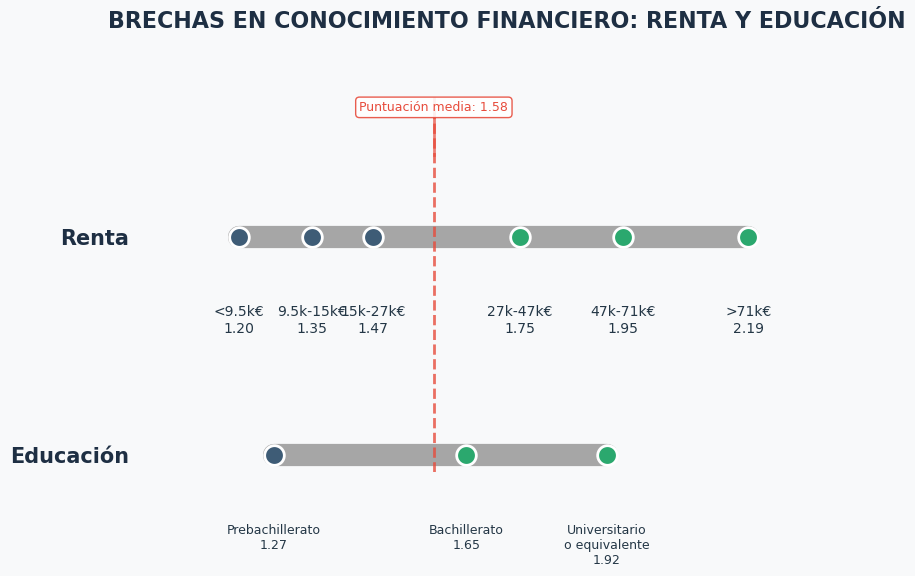


RESUMEN EJECUTIVO - RENTA Y EDUCACIÓN

RENTA:
   Rango total: 1.20 - 2.19 (diferencia: 0.99 pts)
   Categorías:
      • <9.5k€: 1.20 (✗ BAJO media)
      • 9.5k-15k€: 1.35 (✗ BAJO media)
      • 15k-27k€: 1.47 (✗ BAJO media)
      • 27k-47k€: 1.75 (✓ SOBRE media)
      • 47k-71k€: 1.95 (✓ SOBRE media)
      • >71k€: 2.19 (✓ SOBRE media)

EDUCACIÓN:
   Rango total: 1.27 - 1.92 (diferencia: 0.65 pts)
   Categorías:
      • Prebachillerato: 1.27 (✗ BAJO media)
      • Bachillerato: 1.65 (✓ SOBRE media)
      • Universitario o equivalente: 1.92 (✓ SOBRE media)


In [55]:
# ============================================================================
# GRÁFICO : BRECHAS EN RENTA Y EDUCACIÓN (PONDERADO)
# Visual ejecutivo: extremos + media nacional como línea
# ============================================================================

# -------------------------
# Datos
# -------------------------
media = 1.583

# Datos para Renta con todas las categorías
renta_categorias = [
    {'label': '<9.5k€', 'valor': 1.204, 'sobre_media': False},
    {'label': '9.5k-15k€', 'valor': 1.346, 'sobre_media': False},
    {'label': '15k-27k€', 'valor': 1.465, 'sobre_media': False},
    {'label': '27k-47k€', 'valor': 1.750, 'sobre_media': True},
    {'label': '47k-71k€', 'valor': 1.950, 'sobre_media': True},
    {'label': '>71k€', 'valor': 2.194, 'sobre_media': True}
]

# Datos para Educación con todas las categorías
educacion_categorias = [
    {'label': 'Prebachillerato', 'valor': 1.272, 'sobre_media': False},
    {'label': 'Bachillerato', 'valor': 1.646, 'sobre_media': True},
    {'label': 'Universitario\no equivalente', 'valor': 1.919, 'sobre_media': True}
]

datos = [
    {
        'dimension': 'Renta',
        'categorias': renta_categorias,
        'min_val': min(c['valor'] for c in renta_categorias),
        'max_val': max(c['valor'] for c in renta_categorias)
    },
    {
        'dimension': 'Educación',
        'categorias': educacion_categorias,
        'min_val': min(c['valor'] for c in educacion_categorias),
        'max_val': max(c['valor'] for c in educacion_categorias)
    }
]

# Ordenar por rango descendente
datos.sort(key=lambda x: x['max_val'] - x['min_val'], reverse=True)

# -------------------------
# Figura
# -------------------------
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_FONDO)

y_positions = [1, 0]  # Dos posiciones (Renta arriba, Educación abajo)

# Separación vertical
y_separation = 0.8
adjusted_y_positions = [1 * y_separation, 0]

# -------------------------
# Línea vertical de la media nacional
# -------------------------
ax.axvline(x=media, color=COLOR_ROJO, linestyle='--', linewidth=2, alpha=0.8, zorder=2)

# Etiqueta en la parte superior
ax.text(media, max(adjusted_y_positions) + 0.45, f'Puntuación media: {media:.2f}', 
        ha='center', va='bottom', fontsize=9, color=COLOR_ROJO, 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLOR_ROJO, alpha=0.9, linewidth=1))

# Línea decorativa
ax.plot([media, media], [max(adjusted_y_positions) + 0.30, max(adjusted_y_positions) + 0.45], 
        color=COLOR_ROJO, linewidth=2, alpha=0.7)

# -------------------------
# Barras y puntos por segmento
# -------------------------
for idx, (y, d) in enumerate(zip(adjusted_y_positions, datos)):
    # Línea base entre mínimo y máximo
    ax.hlines(y, d['min_val'], d['max_val'], color=COLOR_GRIS, linewidth=16, zorder=1, capstyle='round')
    
    # Para cada categoría, dibujar marcador
    for cat in d['categorias']:
        marker_color = COLOR_VERDE if cat['sobre_media'] else COLOR_AZUL_CLARO
        
        # Punto para la categoría
        ax.scatter(cat['valor'], y, s=200, color=marker_color, zorder=3, edgecolor='white', linewidth=2)
        
        # Etiqueta de la categoría
        offset = -0.25
        fontsize_label = 9 if d['dimension'] == 'Educación' else 10
        
        ax.text(cat['valor'], y + offset, f"{cat['label']}\n{cat['valor']:.2f}",
                ha='center', va='top', fontsize=fontsize_label, color=COLOR_TEXTO)

# -------------------------
# Etiquetas eje Y
# -------------------------
ax.set_yticks(adjusted_y_positions)
ax.set_yticklabels([d['dimension'] for d in datos], fontsize=15, fontweight='bold', color=COLOR_AZUL)

# -------------------------
# Eje X
# -------------------------
ax.set_xlim(1.0, 2.45)
ax.set_xticks([])
ax.tick_params(axis='y', length=0)

# -------------------------
# Título
# -------------------------
ax.set_title(
    "BRECHAS EN CONOCIMIENTO FINANCIERO: RENTA Y EDUCACIÓN",
    fontsize=16, fontweight='bold', color=COLOR_AZUL, pad=50
)

# -------------------------
# Limpieza visual
# -------------------------
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

# -------------------------
# Resumen ejecutivo
# -------------------------
print("\n" + "="*65)
print("RESUMEN EJECUTIVO - RENTA Y EDUCACIÓN")
print("="*65)

for d in datos:
    print(f"\n{d['dimension'].upper()}:")
    print(f"   Rango total: {d['min_val']:.2f} - {d['max_val']:.2f} (diferencia: {(d['max_val'] - d['min_val']):.2f} pts)")
    print("   Categorías:")
    for cat in d['categorias']:
        status = "✓ SOBRE media" if cat['sobre_media'] else "✗ BAJO media"
        print(f"      • {cat['label'].replace('\n', ' ')}: {cat['valor']:.2f} ({status})")
print("="*65)